# PhenoPop Ba/F3 Imatinib — U-MIMIC Function Testing

End-to-end testing of all U-MIMIC modules using real live-cell imaging data from
**Wu et al., PLoS Comp Bio 2024** (PhenoPop stochastic birth-death framework).

**Dataset**: Ba/F3 murine pro-B cells treated with Imatinib
- 11 concentrations (0–5 µM), 14 timepoints (0–39 h, every 3 h)
- Monoclonal populations: sensitive (500/1000 cells) and resistant (250/500 cells)
- Mixture populations: 1:1, 1:2, 2:1, 4:1 (sensitive:resistant), 14 replicates each

This notebook complements `Hafner_GR_Testing.ipynb` (endpoint data) by exercising
U-MIMIC with **dense time-series** data — enabling proper growth-curve fitting,
stochastic trajectory comparison, and richer inference.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Core dynamics
from umimic.dynamics.states import CellType, ModelTopology, StateVector
from umimic.dynamics.rates import RateSet, EmaxHill, ConstantRate
from umimic.dynamics.ode_system import CellDynamicsODE, build_ode_system
from umimic.dynamics.gillespie import GillespieSimulator
from umimic.dynamics.tau_leaping import TauLeapingSimulator
from umimic.dynamics.moment_equations import MomentODE

# Observations
from umimic.observations.cell_counts import CellCountObservation
from umimic.observations.bli import BLIObservation
from umimic.observations.tumor_volume import TumorVolumeObservation
from umimic.observations.biomarkers import BiomarkerObservation
from umimic.observations.multimodal import MultimodalObservation

# Pharmacokinetics
from umimic.pk.compartment import OneCompartmentPK, TwoCompartmentPK
from umimic.pk.dosing import DosingSchedule, Dose
from umimic.pk.exposure import ExposureProfile
from umimic.pk.luciferin import LuciferinKinetics, TissueAttenuation

# Data handling
from umimic.data.schemas import TimeSeriesData, ExperimentalDataset
from umimic.data.loaders import load_csv
from umimic.data.transforms import log_transform, normalize_to_control, interpolate_missing

# Inference
from umimic.inference.likelihood import ModelLikelihood
from umimic.inference.mle import MLEstimator
from umimic.inference.mcmc import MCMCSampler
from umimic.inference.priors import PriorSpec
from umimic.inference.kalman import ExtendedKalmanFilter
from umimic.inference.diagnostics import summarize_mcmc, posterior_predictive_check

# Visualization
from umimic.visualization.style import apply_umimic_style, STATE_COLORS, get_concentration_colors
from umimic.visualization.trajectories import (
    plot_population_trajectories, plot_ensemble, plot_dose_response_trajectories
)
from umimic.visualization.dose_response import (
    plot_rate_dose_response, plot_net_growth_curve, plot_mechanism_comparison
)
from umimic.visualization.posteriors import plot_posterior_marginals, plot_trace, plot_pair

# Pipeline
from umimic.pipeline.config import ExperimentConfig, DynamicsConfig, DosingConfig, SimulationConfig
from umimic.pipeline.experiment import Experiment
from umimic.pipeline.transfer import TransferLearning
from umimic.types import InferenceResult

apply_umimic_style()
print("All U-MIMIC modules imported successfully.")

All U-MIMIC modules imported successfully.


## 1. Load Data from `.csv.xz`

In [2]:
# --- Load compressed CSV ---
DATA_PATH = Path("umimic/data/public/phenopop/phenopop_umimic.csv.xz")
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows from {DATA_PATH.name}")
print(f"Columns: {list(df.columns)}")
print(f"Sources: {df.source.unique()}")
print(f"Populations: {df.population.unique()}")
print(f"Concentrations: {sorted(df.concentration.unique())}")
print(f"Time points: {sorted(df.hours.unique())}")

# --- Build ExperimentalDataset from DataFrame ---
def df_to_dataset(sub_df, name=""):
    """Convert a DataFrame subset into an ExperimentalDataset."""
    series = []
    for rid in sub_df.replicate_id.unique():
        for conc in sub_df.concentration.unique():
            mask = (sub_df.replicate_id == rid) & (sub_df.concentration == conc)
            chunk = sub_df[mask].sort_values("hours")
            if len(chunk) < 2:
                continue
            ts = TimeSeriesData(
                times=chunk.hours.values,
                observations={"cell_counts": chunk.viable_count.values},
                concentration=float(conc),
                group_id=f"{rid}_c{conc}",
            )
            series.append(ts)
    return ExperimentalDataset(series=series, name=name)

# Build separate datasets
mono_df = df[df.source == "monoclonal"]
mix_df = df[df.source == "mixture"]

sens_df = mono_df[mono_df.population == "sensitive"]
res_df = mono_df[mono_df.population == "resistant"]

dataset_sens = df_to_dataset(sens_df, "Ba/F3_sensitive")
dataset_res = df_to_dataset(res_df, "Ba/F3_resistant")
dataset_mix11 = df_to_dataset(mix_df[mix_df.population == "mix_1to1"], "Ba/F3_mix_1:1")

print(f"\nSensitive dataset: {dataset_sens.n_series} series")
print(f"Resistant dataset: {dataset_res.n_series} series")
print(f"Mix 1:1 dataset: {dataset_mix11.n_series} series")
print(f"Concentrations in sensitive: {dataset_sens.concentrations}")

Loaded 11563 rows from phenopop_umimic.csv.xz
Columns: ['hours', 'viable_count', 'concentration', 'replicate_id', 'cell_line', 'drug', 'population', 'initial_cells', 'source', 'sensitive_ratio']
Sources: ['mixture' 'monoclonal']
Populations: ['mix_1to1' 'mix_1to2' 'mix_2to1' 'mix_4to1' 'resistant' 'sensitive']
Concentrations: [np.float64(0.0), np.float64(0.03125), np.float64(0.0625), np.float64(0.125), np.float64(0.25), np.float64(0.375), np.float64(0.5000000000000001), np.float64(1.25), np.float64(2.5), np.float64(3.75), np.float64(5.0)]
Time points: [np.float64(0.0), np.float64(3.0), np.float64(6.0), np.float64(9.0), np.float64(12.0), np.float64(15.0), np.float64(18.0), np.float64(21.0), np.float64(24.0), np.float64(27.0), np.float64(30.0), np.float64(33.0), np.float64(36.0), np.float64(39.0)]

Sensitive dataset: 143 series
Resistant dataset: 131 series
Mix 1:1 dataset: 150 series
Concentrations in sensitive: [0.0, 0.03125, 0.0625, 0.125, 0.25, 0.375, 0.5000000000000001, 1.25, 2.5, 3

## 2. Data Exploration

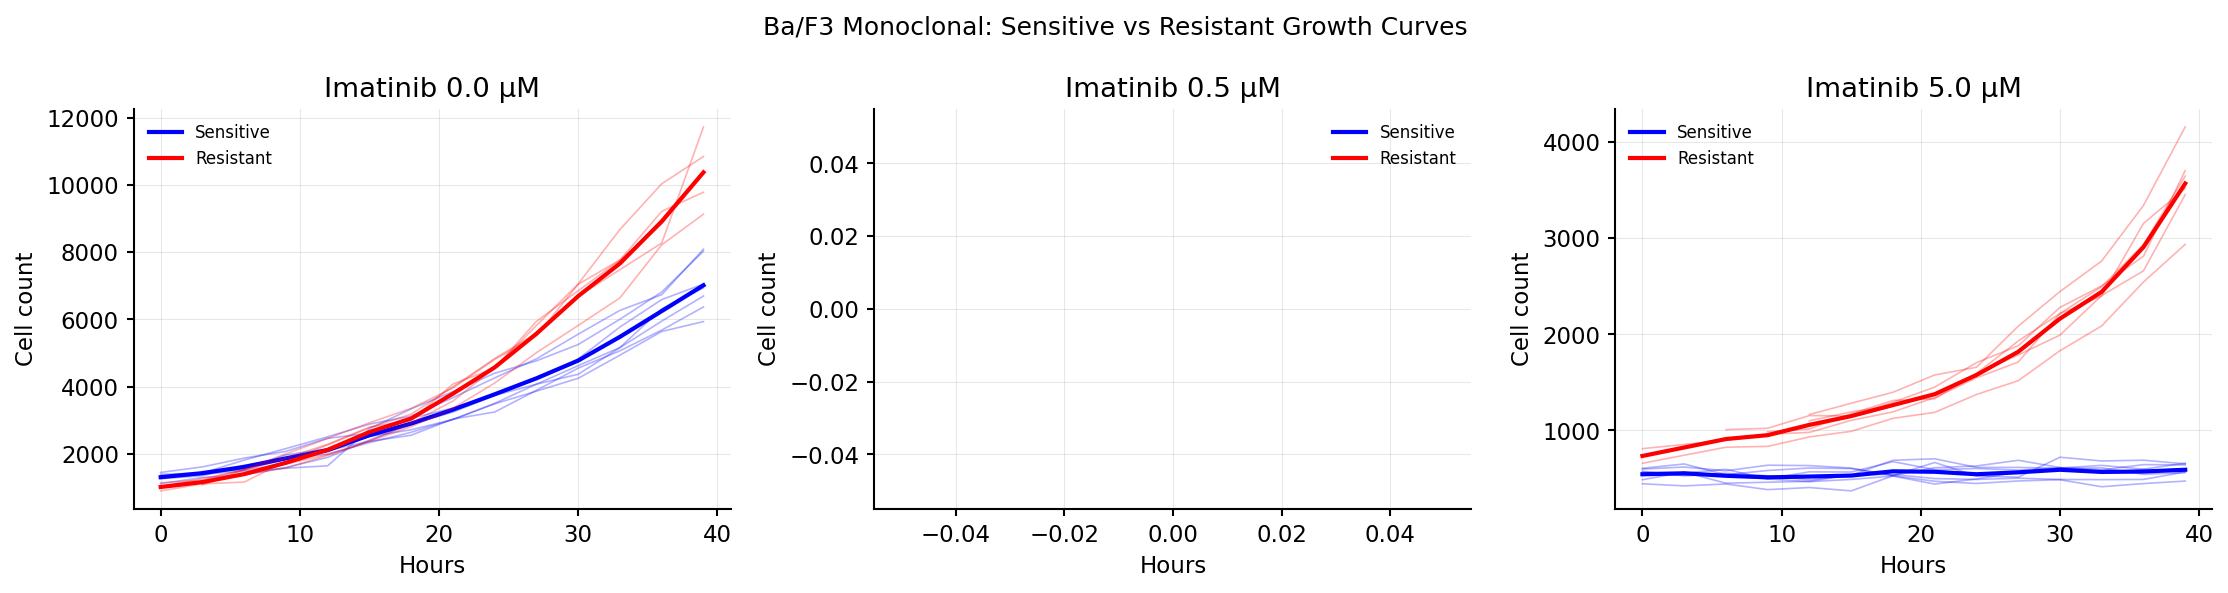

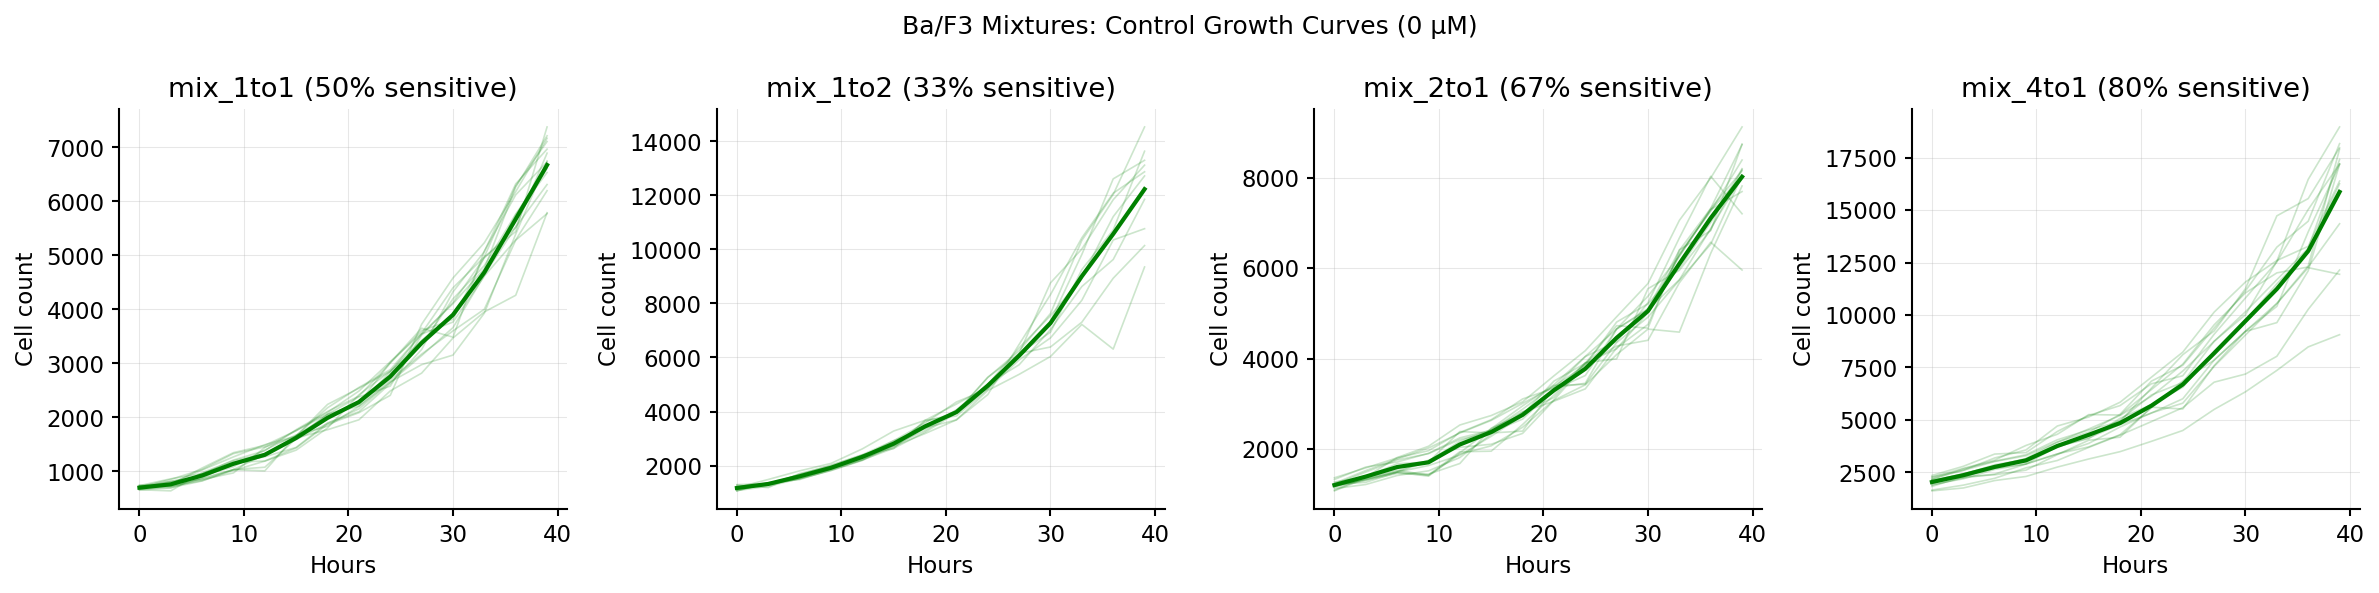

In [3]:
# --- Growth curves: sensitive vs resistant at selected concentrations ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pick representative concentrations
concs_to_plot = [0.0, 0.5, 5.0]

for ax, conc in zip(axes, concs_to_plot):
    # Sensitive (init=500)
    sub_s = sens_df[(sens_df.concentration == conc) & (sens_df.initial_cells == 500)]
    for rid in sub_s.replicate_id.unique():
        rep = sub_s[sub_s.replicate_id == rid].sort_values("hours")
        ax.plot(rep.hours, rep.viable_count, 'b-', alpha=0.3, linewidth=0.8)
    # Mean
    mean_s = sub_s.groupby("hours").viable_count.mean()
    ax.plot(mean_s.index, mean_s.values, 'b-', linewidth=2, label="Sensitive")

    # Resistant (init=500)
    sub_r = res_df[(res_df.concentration == conc) & (res_df.initial_cells == 500)]
    for rid in sub_r.replicate_id.unique():
        rep = sub_r[sub_r.replicate_id == rid].sort_values("hours")
        ax.plot(rep.hours, rep.viable_count, 'r-', alpha=0.3, linewidth=0.8)
    mean_r = sub_r.groupby("hours").viable_count.mean()
    ax.plot(mean_r.index, mean_r.values, 'r-', linewidth=2, label="Resistant")

    ax.set_title(f"Imatinib {conc} µM")
    ax.set_xlabel("Hours")
    ax.set_ylabel("Cell count")
    ax.legend(fontsize=8)

plt.suptitle("Ba/F3 Monoclonal: Sensitive vs Resistant Growth Curves", fontsize=12)
plt.tight_layout()
plt.show()

# --- Mixture growth curves ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, pop in zip(axes, ['mix_1to1', 'mix_1to2', 'mix_2to1', 'mix_4to1']):
    sub = mix_df[(mix_df.population == pop) & (mix_df.concentration == 0.0)]
    for rid in sub.replicate_id.unique():
        rep = sub[sub.replicate_id == rid].sort_values("hours")
        ax.plot(rep.hours, rep.viable_count, 'g-', alpha=0.2, linewidth=0.8)
    mean_m = sub.groupby("hours").viable_count.mean()
    ax.plot(mean_m.index, mean_m.values, 'g-', linewidth=2)
    ratio = sub.sensitive_ratio.iloc[0]
    ax.set_title(f"{pop} ({ratio:.0%} sensitive)")
    ax.set_xlabel("Hours")
    ax.set_ylabel("Cell count")

plt.suptitle("Ba/F3 Mixtures: Control Growth Curves (0 µM)", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Data Transforms

Test `log_transform`, `normalize_to_control`, and `interpolate_missing` on PhenoPop data.

In [4]:
# Pick a sensitive replicate at control (conc=0)
test_series = dataset_sens.by_concentration(0.0)[0]
print(f"Original counts (first 5): {test_series.observations['cell_counts'][:5]}")

# --- log_transform ---
log_series = log_transform(test_series, modality="cell_counts")
print(f"Log-transformed (first 5): {log_series.observations['cell_counts'][:5]}")

# --- normalize_to_control ---
control_val = float(test_series.observations['cell_counts'][0])  # t=0 count
norm_series = normalize_to_control(test_series, control_value=control_val, modality="cell_counts")
print(f"Normalized to t=0 (first 5): {norm_series.observations['cell_counts'][:5]}")

# --- interpolate_missing (inject NaNs, then fill) ---
nan_series = TimeSeriesData(
    times=test_series.times.copy(),
    observations={"cell_counts": test_series.observations["cell_counts"].copy()},
    concentration=test_series.concentration,
    group_id=test_series.group_id,
)
nan_series.observations["cell_counts"][3] = np.nan
nan_series.observations["cell_counts"][7] = np.nan
print(f"\nWith NaNs at idx 3,7: {nan_series.observations['cell_counts'][:10]}")

interp_series = interpolate_missing(nan_series, modality="cell_counts")
print(f"After interpolation:  {interp_series.observations['cell_counts'][:10]}")
print(f"NaN count before: {np.isnan(nan_series.observations['cell_counts']).sum()}")
print(f"NaN count after:  {np.isnan(interp_series.observations['cell_counts']).sum()}")

Original counts (first 5): [2305. 2783. 3072. 4269. 4852.]
Log-transformed (first 5): [7.74283596 7.93128476 8.03008409 8.35913489 8.48714627]
Normalized to t=0 (first 5): [1.         1.20737527 1.33275488 1.85206074 2.10498915]

With NaNs at idx 3,7: [2305. 2783. 3072.   nan 4852. 5458. 5974.   nan 8101. 8970.]
After interpolation:  [2305.  2783.  3072.  3962.  4852.  5458.  5974.  7037.5 8101.  8970. ]
NaN count before: 2
NaN count after:  0


## 4. Model Topology & Cell States

In [5]:
# --- Test all topology constructors ---
for name, topo in [("2-state", ModelTopology.two_state()),
                    ("3-state", ModelTopology.three_state()),
                    ("4-state", ModelTopology.four_state())]:
    print(f"{name}: states={[s.name for s in topo.active_states]}, "
          f"n_states={topo.n_states}, "
          f"transitions={[(s.name,t.name) for s,t in topo.transitions]}")

# --- Use 2-state (P-Q) for main analysis ---
topology = ModelTopology.two_state()
print(f"\nSelected topology: {[s.name for s in topology.active_states]}")
print(f"Division states: {[s.name for s in topology.division_states]}")
print(f"Death states: {[s.name for s in topology.death_states]}")

# --- StateVector ---
sv = StateVector(populations={CellType.P: 700.0, CellType.Q: 0.0})
print(f"\nStateVector: {sv}")
print(f"As array: {sv.as_array()}, viable={sv.viable}, total={sv.total}")

# from_array constructor
sv2 = StateVector.from_array(np.array([700.0, 50.0, 0.0, 0.0]), time=0.0)
print(f"From array: {sv2}")

2-state: states=['P', 'Q'], n_states=2, transitions=[('P', 'Q'), ('Q', 'P')]
3-state: states=['P', 'Q', 'A'], n_states=3, transitions=[('P', 'Q'), ('Q', 'P')]
4-state: states=['P', 'Q', 'A', 'R'], n_states=4, transitions=[('P', 'Q'), ('Q', 'P'), ('P', 'R')]

Selected topology: ['P', 'Q']
Division states: ['P']
Death states: ['P', 'Q']

StateVector: StateVector(t=0.00, P=700.0)
As array: [700.   0.   0.   0.], viable=700.0, total=700.0
From array: StateVector(t=0.00, P=700.0, Q=50.0)


## 5. Rate Parameters & Dose-Response

Create rate sets for Imatinib acting on Ba/F3 cells. Imatinib is primarily
cytotoxic for sensitive cells (BCR-ABL inhibition → apoptosis) and has
minimal effect on resistant cells.

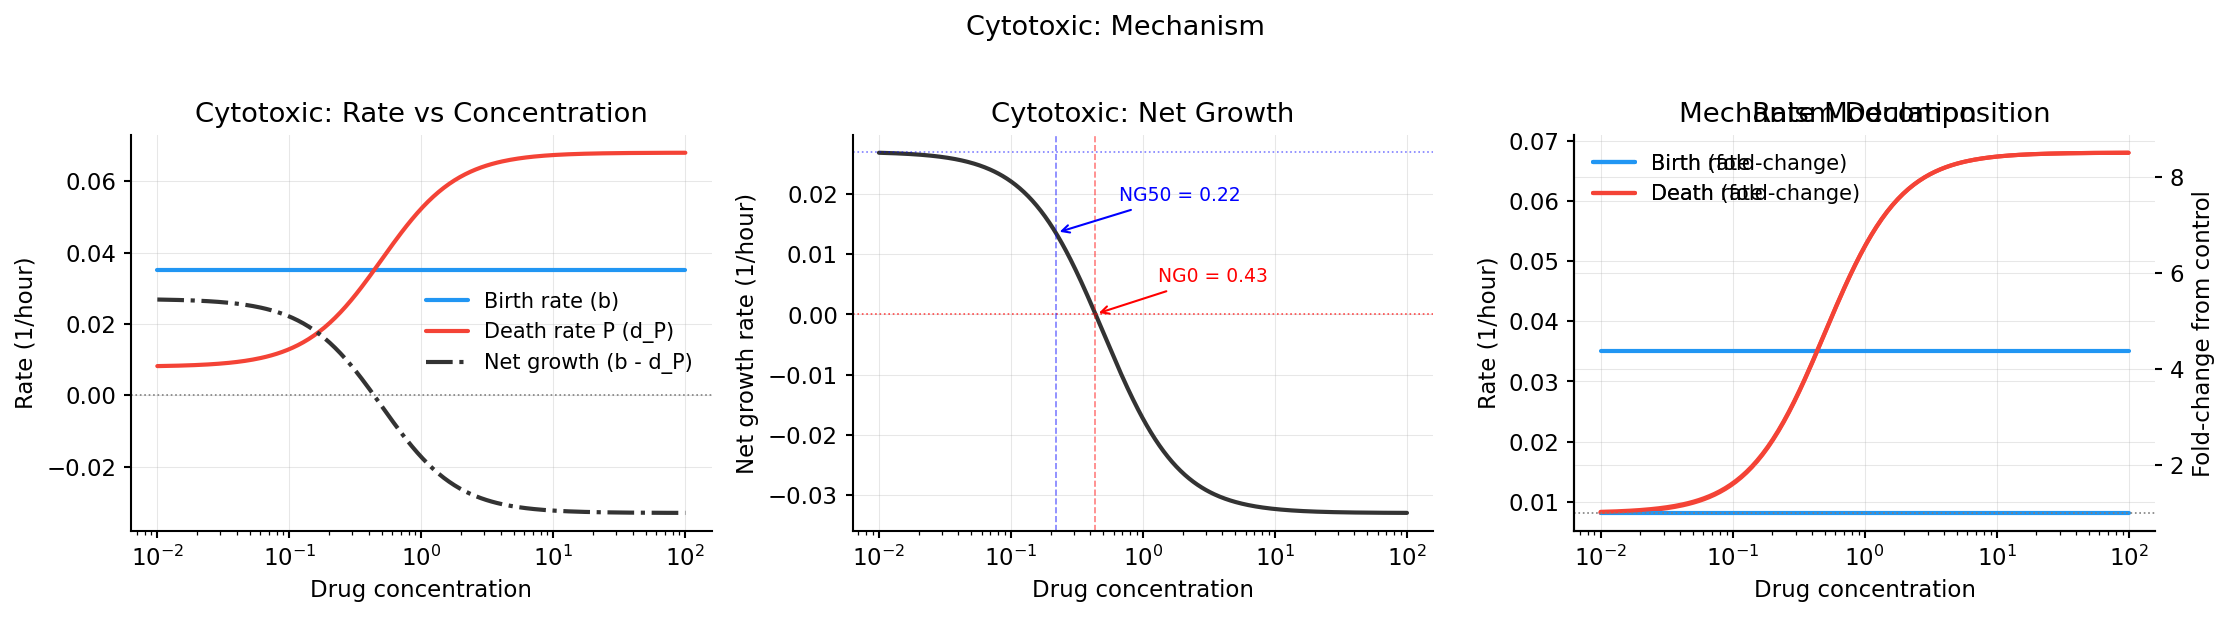

Conc=0.00 µM: net_growth=0.0270/h, doubling_time=25.7h
Conc=0.25 µM: net_growth=0.0113/h, doubling_time=61.2h
Conc=1.00 µM: net_growth=-0.0173/h, doubling_time=693147.2h
Conc=5.00 µM: net_growth=-0.0312/h, doubling_time=693147.2h


In [6]:
# --- Cytotoxic rate set (Imatinib on sensitive Ba/F3) ---
# Ba/F3 doubling time ~18-24h → b0 ~ 0.03-0.04/h
rate_set_sens = RateSet.cytotoxic_drug(
    b0=0.035,         # birth rate
    d0=0.008,         # baseline death
    emax_death=0.06,  # strong cytotoxic effect
    ec50_death=0.5,   # EC50 ~ 0.5 µM for sensitive
    hill_death=1.5,
)

# --- Cytostatic rate set (for comparison) ---
rate_set_static = RateSet.cytostatic_drug(
    b0=0.035,
    d0=0.008,
    emax_birth=0.9,
    ec50_birth=0.5,
    hill_birth=1.5,
)

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_rate_dose_response(rate_set_sens, ax=axes[0], title="Cytotoxic: Rate vs Concentration")
plot_net_growth_curve(rate_set_sens, ax=axes[1], title="Cytotoxic: Net Growth")
plot_mechanism_comparison(rate_set_sens, ax=axes[2], title="Cytotoxic: Mechanism")

plt.tight_layout()
plt.show()

# Print rates at selected concentrations
for conc in [0.0, 0.25, 1.0, 5.0]:
    ng = rate_set_sens.net_growth_rate(conc)
    print(f"Conc={conc:.2f} µM: net_growth={ng:.4f}/h, "
          f"doubling_time={np.log(2)/max(ng,1e-6):.1f}h")

## 6. Forward Simulation — ODE

Simulate population dynamics at multiple Imatinib concentrations and overlay
real Ba/F3 sensitive data.

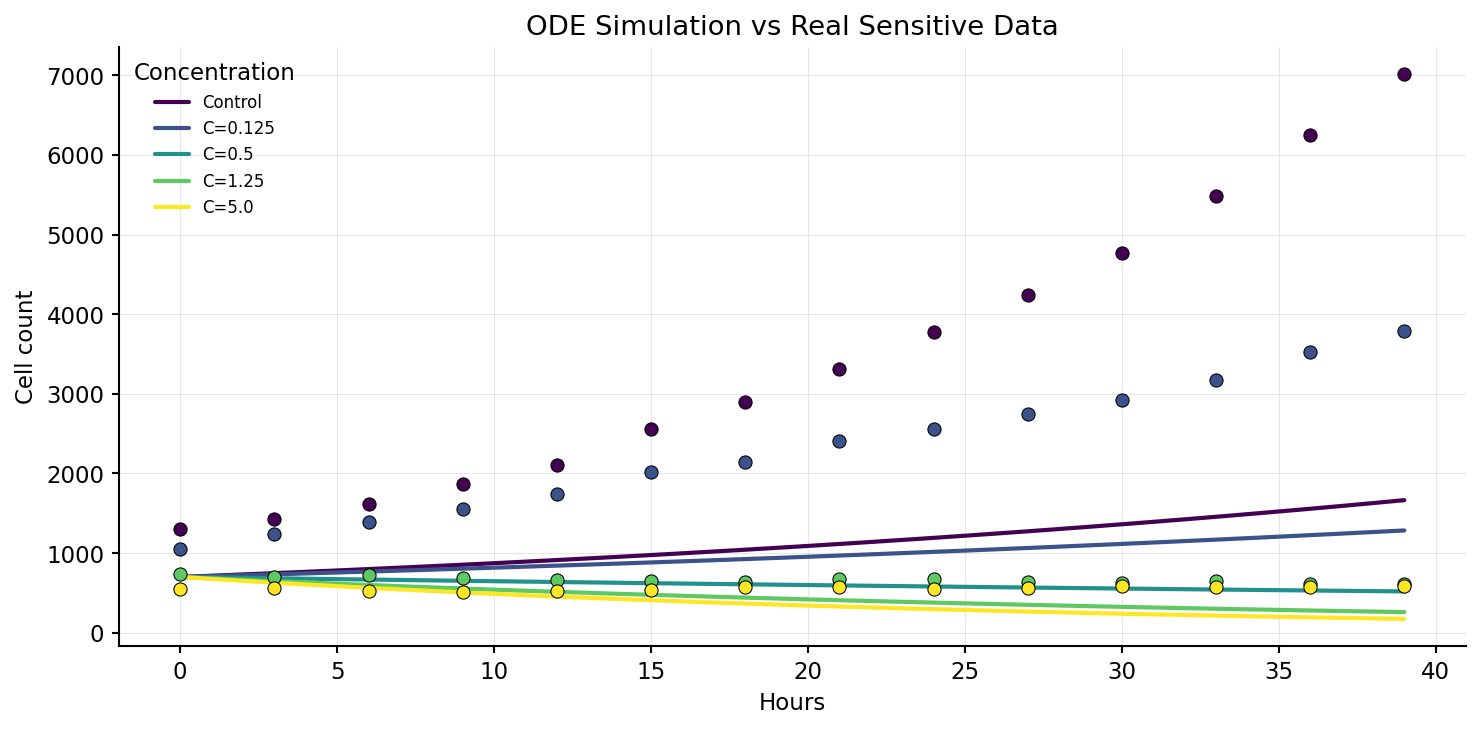

Single ODE result at 1.0 µM: viable=376 at t=39h
Populations: ['P', 'Q']
Solver metadata: {'method': 'RK45', 'success': True, 'nfev': 98}


In [7]:
# --- ODE simulation ---
concentrations = [0.0, 0.125, 0.5, 1.25, 5.0]
t_eval = np.linspace(0, 39, 100)
y0 = np.array([700.0, 0.0])  # P=700, Q=0 (typical Ba/F3 sensitive init)

ode = build_ode_system(rate_set_sens, topology, constant_concentration=0.0)
dose_results = ode.solve_dose_response(y0, (0, 39), concentrations, t_eval)

# --- Plot with U-MIMIC viz + real data overlay ---
fig, ax = plt.subplots(figsize=(10, 5))
plot_dose_response_trajectories(dose_results, state="P", ax=ax,
                                 title="ODE Simulation vs Real Sensitive Data")

# Overlay real data (sensitive, init=500)
colors = get_concentration_colors(concentrations)
for conc, color in zip(concentrations, colors):
    sub = sens_df[(sens_df.concentration == conc) & (sens_df.initial_cells == 500)]
    mean_data = sub.groupby("hours").viable_count.mean()
    ax.scatter(mean_data.index, mean_data.values, color=color, s=40,
              zorder=5, edgecolors='k', linewidth=0.5)

ax.set_xlabel("Hours")
ax.set_ylabel("Cell count")
plt.tight_layout()
plt.show()

# --- Also test single-concentration solve + build_ode_system ---
ode_single = build_ode_system(rate_set_sens, topology, constant_concentration=1.0)
result_single = ode_single.solve(y0, (0, 39), t_eval)
print(f"Single ODE result at 1.0 µM: viable={result_single.viable[-1]:.0f} at t=39h")
print(f"Populations: {list(result_single.populations.keys())}")
print(f"Solver metadata: {result_single.metadata}")

## 7. Stochastic Simulation — Gillespie SSA

With dense timepoints, we can compare stochastic trajectories to real
replicate variability in the Ba/F3 data.

Gillespie ensemble: 50 trajectories
P mean at t=39: 510 ± 33


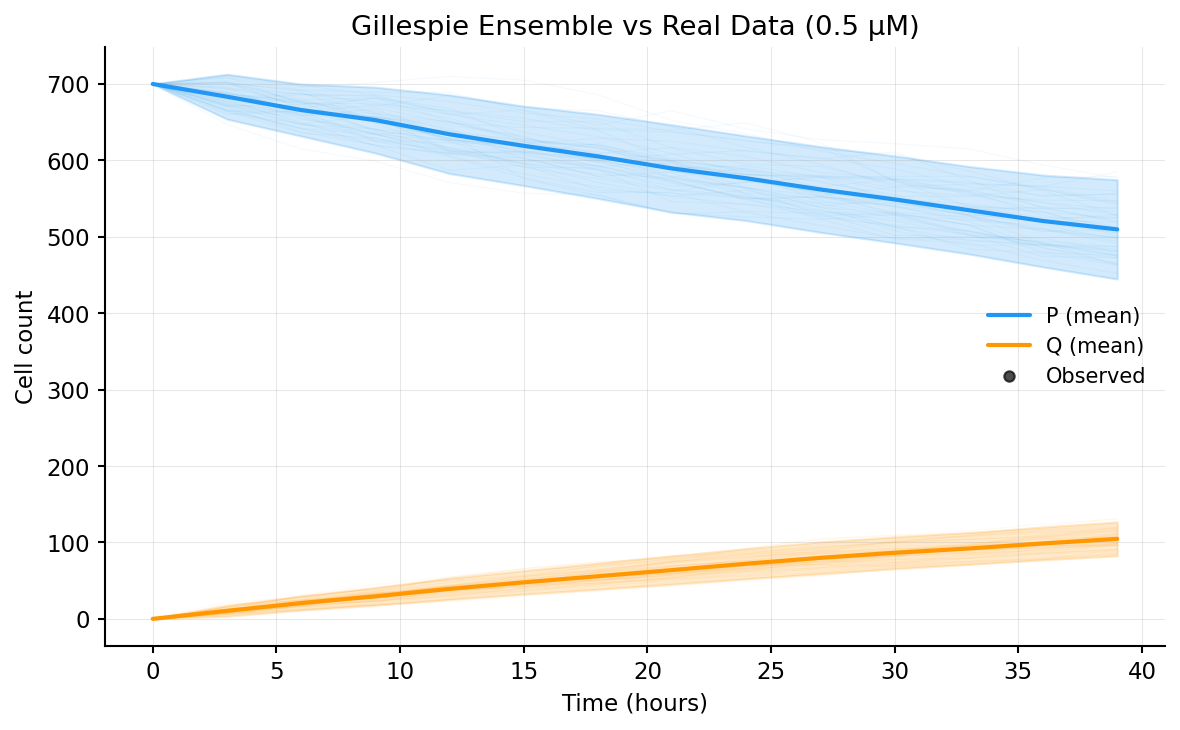

In [8]:
# --- Gillespie at moderate Imatinib concentration ---
rng = np.random.default_rng(42)
exposure_fn = lambda t: 0.5  # 0.5 µM
y0_int = np.array([700, 0])  # start with ~700 cells
t_obs = np.arange(0, 39.1, 3.0)  # match real data timepoints

sim_gill = GillespieSimulator(rate_set_sens, topology, exposure_fn, rng)
ensemble_gill = sim_gill.simulate_ensemble(y0_int, t_max=39.0, t_record=t_obs, n_trajectories=50)

print(f"Gillespie ensemble: {ensemble_gill.n_trajectories} trajectories")
means = ensemble_gill.mean()
stds = ensemble_gill.std()
print(f"P mean at t=39: {means['P'][-1]:.0f} ± {stds['P'][-1]:.0f}")

# --- Plot with real data overlay ---
fig, ax = plt.subplots(figsize=(8, 5))

# Build a TimeSeriesData from real data for overlay
real_sub = sens_df[(sens_df.concentration == 0.5) & (sens_df.initial_cells == 500)]
real_mean = real_sub.groupby("hours").viable_count.mean()
real_data = TimeSeriesData(
    times=real_mean.index.values,
    observations={"cell_counts": real_mean.values},
    concentration=0.5,
)

plot_ensemble(ensemble_gill, data=real_data, ax=ax,
              title="Gillespie Ensemble vs Real Data (0.5 µM)")
plt.tight_layout()
plt.show()

## 8. Stochastic Simulation — Tau-Leaping

Tau-leaping ensemble: 50 trajectories
P mean at t=39: 516 ± 36


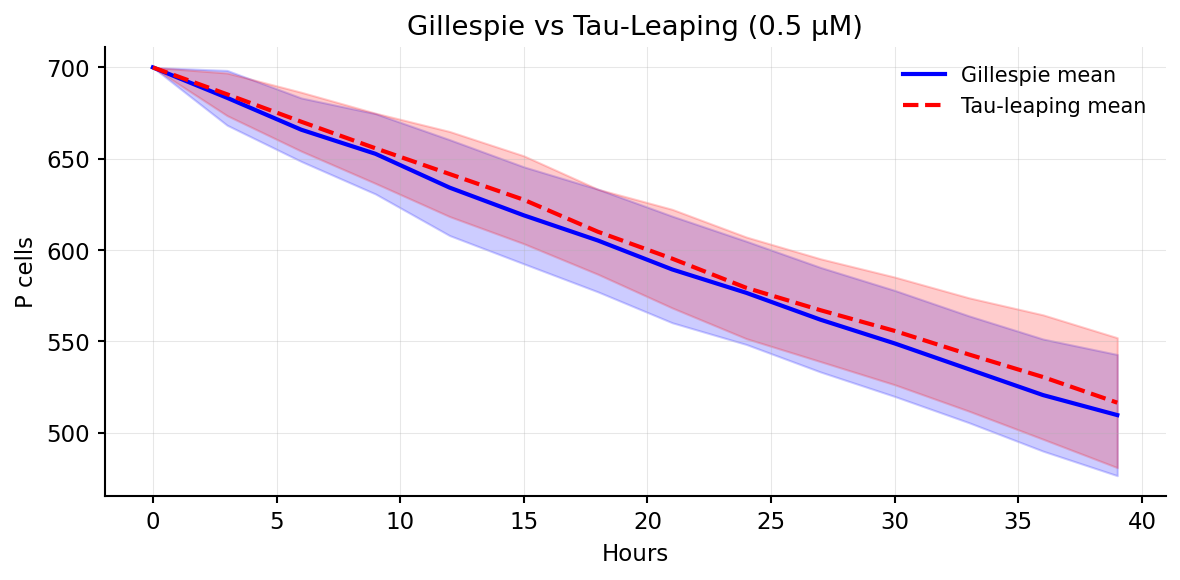

In [9]:
# --- Tau-leaping for speed comparison ---
sim_tau = TauLeapingSimulator(rate_set_sens, topology, exposure_fn, rng=rng)
ensemble_tau = sim_tau.simulate_ensemble(y0_int, t_max=39.0, t_record=t_obs, n_trajectories=50)

print(f"Tau-leaping ensemble: {ensemble_tau.n_trajectories} trajectories")
means_tau = ensemble_tau.mean()
stds_tau = ensemble_tau.std()
print(f"P mean at t=39: {means_tau['P'][-1]:.0f} ± {stds_tau['P'][-1]:.0f}")

# --- Compare Gillespie vs Tau-leaping ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_obs, means['P'], 'b-', linewidth=2, label='Gillespie mean')
ax.fill_between(t_obs, means['P'] - stds['P'], means['P'] + stds['P'],
                alpha=0.2, color='blue')
ax.plot(t_obs, means_tau['P'], 'r--', linewidth=2, label='Tau-leaping mean')
ax.fill_between(t_obs, means_tau['P'] - stds_tau['P'],
                means_tau['P'] + stds_tau['P'], alpha=0.2, color='red')
ax.set_xlabel("Hours")
ax.set_ylabel("P cells")
ax.set_title("Gillespie vs Tau-Leaping (0.5 µM)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Moment Equations (Linear Noise Approximation)

Propagate mean + covariance via the LNA. Compare LNA mean to ODE solution.

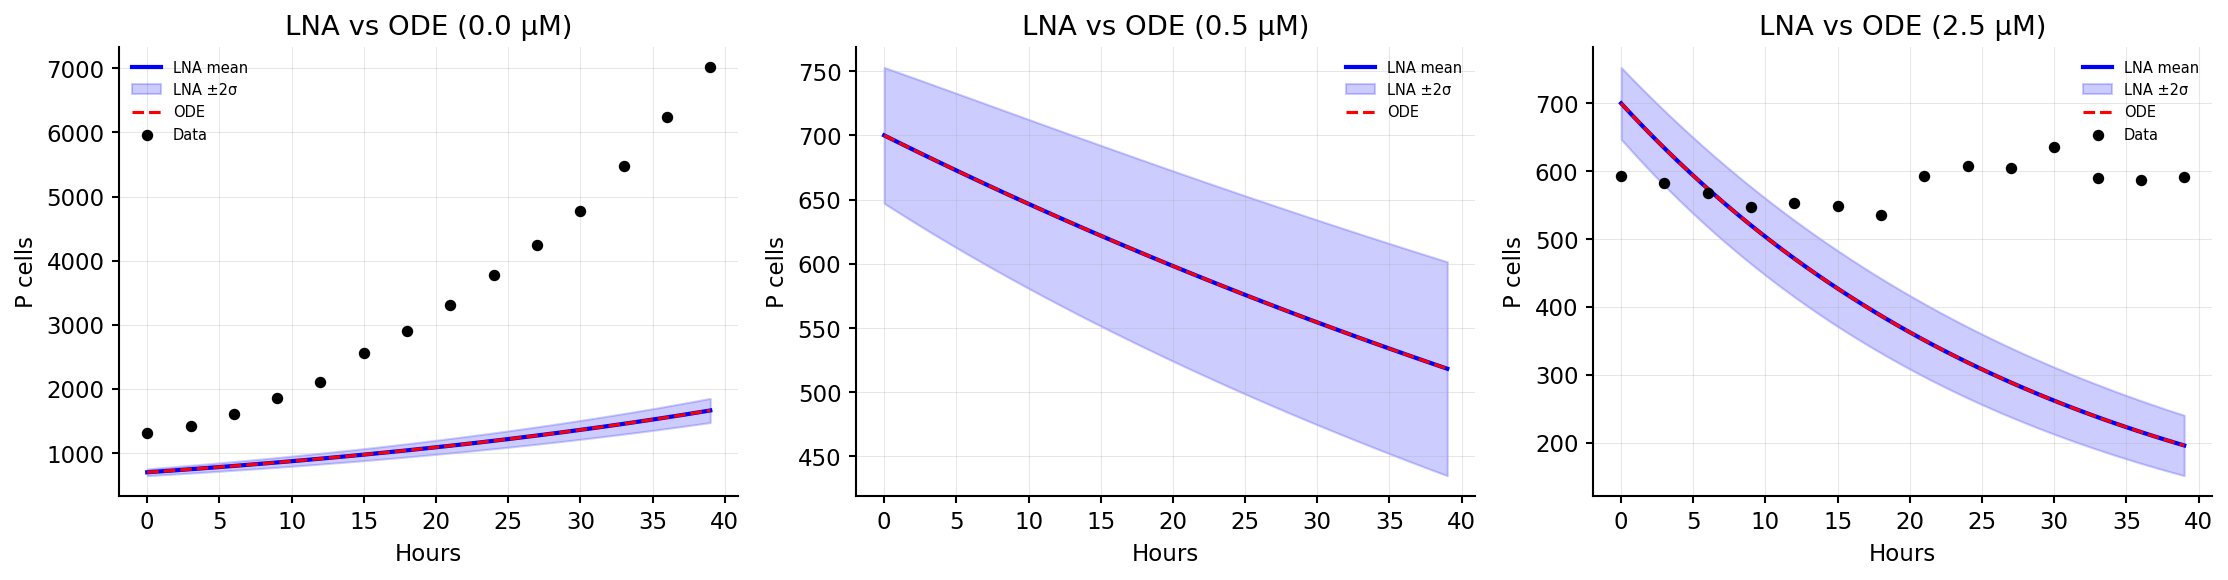

Max |LNA_mean - ODE| at 2.5 µM: 0.0000 (should be ~0)


In [10]:
# --- LNA at multiple concentrations ---
mu0 = np.array([700.0, 0.0])
lna_concs = [0.0, 0.5, 2.5]
t_eval_lna = np.linspace(0, 39, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, conc in zip(axes, lna_concs):
    exposure_c = lambda t, c=conc: c
    moment_ode = MomentODE(rate_set_sens, topology, exposure_c)
    t_sol, means_lna, covs_lna = moment_ode.solve(
        mu0, t_span=(0, 39), t_eval=t_eval_lna
    )

    # Also solve deterministic ODE for comparison
    ode_c = build_ode_system(rate_set_sens, topology, constant_concentration=conc)
    result_ode = ode_c.solve(mu0, (0, 39), t_eval_lna)

    # LNA mean
    P_mean = means_lna[:, 0]
    P_var = covs_lna[:, 0, 0]
    P_std = np.sqrt(np.maximum(P_var, 0))

    ax.plot(t_sol, P_mean, 'b-', linewidth=2, label='LNA mean')
    ax.fill_between(t_sol, P_mean - 2*P_std, P_mean + 2*P_std,
                    alpha=0.2, color='blue', label='LNA ±2σ')
    ax.plot(result_ode.times, result_ode.populations['P'], 'r--',
            linewidth=1.5, label='ODE')

    # Overlay real data
    sub = sens_df[(sens_df.concentration == conc) & (sens_df.initial_cells == 500)]
    if len(sub) > 0:
        mean_data = sub.groupby("hours").viable_count.mean()
        ax.scatter(mean_data.index, mean_data.values, c='k', s=20, zorder=5, label='Data')

    ax.set_title(f"LNA vs ODE ({conc} µM)")
    ax.set_xlabel("Hours")
    ax.set_ylabel("P cells")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Verify LNA mean matches ODE
diff = np.max(np.abs(P_mean - result_ode.populations['P']))
print(f"Max |LNA_mean - ODE| at 2.5 µM: {diff:.4f} (should be ~0)")

## 10. Observation Models

Test all five observation model types.

In [11]:
# --- CellCountObservation on real data ---
obs_cc = CellCountObservation(overdispersion=10.0)
latent_state = np.array([800.0, 50.0])  # P=800, Q=50
obs_params = {"overdispersion": 10.0}

# Likelihood of observing a real data point
real_count = 850.0
ll_cc = obs_cc.log_likelihood(real_count, latent_state, obs_params)
print(f"CellCount LL(obs={real_count}, expected={sum(latent_state)}): {ll_cc:.4f}")

# Sample and expected value
sample_rng = np.random.default_rng(42)
sample_cc = obs_cc.sample(latent_state, sample_rng, obs_params)
expected_cc = obs_cc.expected_value(latent_state)
print(f"CellCount sample: {sample_cc:.0f}, expected: {expected_cc:.0f}")

# Batch log-likelihood (vectorized)
real_data_slice = dataset_sens.by_concentration(0.0)[0]
obs_vec = real_data_slice.observations['cell_counts']
n_t = len(obs_vec)
latent_batch = np.column_stack([np.linspace(700, 2000, n_t), np.zeros(n_t)])
ll_batch = obs_cc.log_likelihood_batch(obs_vec, latent_batch, obs_params)
ll_loop = sum(obs_cc.log_likelihood(obs_vec[i], latent_batch[i], obs_params) for i in range(n_t))
print(f"\nBatch LL: {ll_batch:.4f}, Loop LL: {ll_loop:.4f}, Match: {abs(ll_batch - ll_loop) < 0.01}")

# --- BLI observation (synthetic state) ---
obs_bli = BLIObservation(alpha=1000.0, sigma_log=0.3)
ll_bli = obs_bli.log_likelihood(850000.0, latent_state, {"alpha": 1000.0, "sigma_log": 0.3})
print(f"\nBLI LL: {ll_bli:.4f}")

# --- TumorVolume observation ---
obs_tv = TumorVolumeObservation(beta=1e-3, sigma_v=0.2)
ll_tv = obs_tv.log_likelihood(0.85, latent_state, {"beta": 1e-3, "sigma_v": 0.2})
print(f"TumorVolume LL: {ll_tv:.4f}")

# --- Biomarker observation ---
obs_bm = BiomarkerObservation(precision=50.0)
ll_bm = obs_bm.log_likelihood(0.94, latent_state, {"precision": 50.0})
print(f"Biomarker LL: {ll_bm:.4f}")

# --- Multimodal observation ---
obs_multi = MultimodalObservation({
    "cell_counts": obs_cc,
    "bli": obs_bli,
    "volume": obs_tv,
    "biomarker": obs_bm,
})
multi_obs = {"cell_counts": 850.0, "bli": 850000.0, "volume": 0.85, "biomarker": 0.94}
multi_params = {"overdispersion": 10.0, "alpha": 1000.0, "sigma_log": 0.3,
                "beta": 1e-3, "sigma_v": 0.2, "precision": 50.0}
ll_multi = obs_multi.log_likelihood(multi_obs, latent_state, multi_params)
print(f"\nMultimodal LL: {ll_multi:.4f}")
print(f"Sum of individual LLs: {ll_cc + ll_bli + ll_tv + ll_bm:.4f}")

CellCount LL(obs=850.0, expected=850.0): -6.5271
CellCount sample: 942, expected: 850

Batch LL: -447.6246, Loop LL: -447.6246, Match: True

BLI LL: -13.3680
TumorVolume LL: 0.8530
Biomarker LL: 2.4365

Multimodal LL: -16.6055
Sum of individual LLs: -16.6055


## 11. Likelihood Function

Build `ModelLikelihood` using sensitive Ba/F3 data. With 14 timepoints the
likelihood landscape is much more informative than endpoint-only data.

In [12]:
# --- Build likelihood with sensitive data at a few concentrations ---
# Use init=500 sensitive data: pick 3 concs, 2 reps each for speed
sens500_df = sens_df[sens_df.initial_cells == 500]
test_concs = [0.0, 0.5, 2.5]
test_reps = ['SENSITIVE_500_BF_rep0', 'SENSITIVE_500_BF_rep1']

lik_data = []
for conc in test_concs:
    for rid in test_reps:
        sub = sens500_df[(sens500_df.concentration == conc) & (sens500_df.replicate_id == rid)]
        sub = sub.sort_values("hours")
        if len(sub) < 2:
            continue
        ts = TimeSeriesData(
            times=sub.hours.values,
            observations={"cell_counts": sub.viable_count.values},
            concentration=float(conc),
            group_id=f"{rid}_c{conc}",
        )
        lik_data.append(ts)

print(f"Built {len(lik_data)} series for likelihood")

obs_model = CellCountObservation(overdispersion=10.0)

# --- Moment mode ---
lik_moment = ModelLikelihood(
    topology=topology, data=lik_data,
    mode="moment", observation_model=obs_model
)

# Evaluate at a reasonable parameter vector
theta_test = np.array([0.035, 0.008, 0.06, 0.5, 1.5, 0.005, 0.003, 10.0])
ll_moment = lik_moment(theta_test)
print(f"\nMoment-mode LL: {ll_moment:.2f}")
print(f"n_params: {lik_moment.n_params}, param_names: {lik_moment.param_names}")

# --- ODE mode ---
lik_ode = ModelLikelihood(
    topology=topology, data=lik_data,
    mode="ode", observation_model=obs_model
)
ll_ode = lik_ode(theta_test)
print(f"ODE-mode LL: {ll_ode:.2f}")

# --- Test convenience methods ---
nll = lik_moment.neg_log_likelihood(theta_test)
params_dict = lik_moment.theta_to_params(theta_test)
theta_back = lik_moment.params_to_theta(params_dict)
print(f"\nneg_log_likelihood: {nll:.2f}")
print(f"theta_to_params: {params_dict}")
print(f"Roundtrip match: {np.allclose(theta_test, theta_back)}")
print(f"n_evaluations: {lik_moment.n_evaluations}")

Built 4 series for likelihood

Moment-mode LL: -564.46
n_params: 8, param_names: ['b0', 'd0_P', 'emax_death', 'ec50_death', 'hill_death', 'u_PQ', 'u_QP', 'overdispersion']
ODE-mode LL: -496.11

neg_log_likelihood: 564.46
theta_to_params: {'b0': np.float64(0.035), 'd0_P': np.float64(0.008), 'emax_death': np.float64(0.06), 'ec50_death': np.float64(0.5), 'hill_death': np.float64(1.5), 'u_PQ': np.float64(0.005), 'u_QP': np.float64(0.003), 'overdispersion': np.float64(10.0)}
Roundtrip match: True
n_evaluations: 2


## 12. MLE — Sensitive Ba/F3 with Imatinib

Fit the 2-state model to sensitive cell data. Compare 2-state vs 3-state AIC/BIC.

In [13]:
# --- MLE with 2-state model ---
estimator = MLEstimator(
    likelihood=lik_moment,
    method="L-BFGS-B",
)

print("Running MLE (2-state, L-BFGS-B, 5 restarts)...")
mle_result = estimator.fit(initial_guess=theta_test, n_restarts=5)
print(f"Converged: {mle_result.converged}")
print(f"Log-likelihood: {mle_result.log_likelihood:.2f}")
print(f"AIC: {mle_result.aic:.2f}, BIC: {mle_result.bic:.2f}")
print(f"N evaluations: {mle_result.n_evaluations}")

print(f"\n{'Parameter':>15} | {'Estimate':>10} | {'SE':>10}")
print("-" * 42)
for name, val in mle_result.parameters.items():
    se = mle_result.se.get(name, float('nan')) if mle_result.se else float('nan')
    print(f"{name:>15} | {val:>10.5f} | {se:>10.5f}")

# --- Model comparison: 3-state ---
topo3 = ModelTopology.three_state()
param_names_3 = [
    "b0", "d0_P", "emax_death", "ec50_death", "hill_death",
    "u_PQ", "u_QP", "u_PR", "overdispersion",
]
lik_3state = ModelLikelihood(
    topology=topo3, data=lik_data,
    param_names=param_names_3,
    mode="moment", observation_model=obs_model
)
est_3 = MLEstimator(likelihood=lik_3state, method="L-BFGS-B")
print("\nRunning MLE (3-state)...")
mle_3 = est_3.fit(n_restarts=3)

print(f"\nModel Comparison:")
print(f"{'Model':>10} | {'LL':>10} | {'AIC':>10} | {'BIC':>10} | {'n_params':>8}")
print("-" * 56)
print(f"{'2-state':>10} | {mle_result.log_likelihood:>10.2f} | {mle_result.aic:>10.2f} | {mle_result.bic:>10.2f} | {lik_moment.n_params:>8}")
print(f"{'3-state':>10} | {mle_3.log_likelihood:>10.2f} | {mle_3.aic:>10.2f} | {mle_3.bic:>10.2f} | {lik_3state.n_params:>8}")

Running MLE (2-state, L-BFGS-B, 5 restarts)...
Converged: True
Log-likelihood: -341.69
AIC: 699.37, BIC: 715.43
N evaluations: 2083

      Parameter |   Estimate |         SE
------------------------------------------
             b0 |    0.05069 |    0.11894
           d0_P |    0.00860 |    0.11814
     emax_death |    0.26715 |    0.03537
     ec50_death |    6.72908 |    0.44210
     hill_death |    1.82652 |    0.08200
           u_PQ |    0.00128 |    0.00361
           u_QP |    0.05000 |    0.15016
 overdispersion |  155.71656 |   30.93445

Running MLE (3-state)...

Model Comparison:
     Model |         LL |        AIC |        BIC | n_params
--------------------------------------------------------
   2-state |    -341.69 |     699.37 |     715.43 |        8
   3-state |    -341.27 |     700.54 |     718.60 |        9


## 13. MCMC — Bayesian Inference

In [14]:
# --- Set up priors ---
priors = PriorSpec.default_invitro()
print(f"Prior parameters: {list(priors.distributions.keys())}")

# --- Use a smaller data subset for MCMC speed ---
mcmc_data = lik_data[:4]  # 4 series (2 concs × 2 reps)
lik_mcmc = ModelLikelihood(
    topology=topology, data=mcmc_data,
    mode="moment", observation_model=obs_model
)

sampler = MCMCSampler(likelihood=lik_mcmc, priors=priors, backend="emcee")

print("Running MCMC (short run for testing)...")
mcmc_result = sampler.sample(
    n_samples=500, n_warmup=300, n_chains=4,
    initial_guess=np.array(list(mle_result.parameters.values()))
)
print("Done!")

# --- Posterior summaries ---
means_post = mcmc_result.posterior_mean()
stds_post = mcmc_result.posterior_std()
cis = mcmc_result.credible_interval(alpha=0.05)

print(f"\n{'Parameter':>15} | {'Mean':>10} | {'Std':>10} | {'95% CI':>22}")
print("-" * 65)
for name in means_post:
    ci = cis[name]
    print(f"{name:>15} | {means_post[name]:>10.4f} | {stds_post[name]:>10.4f} | [{ci[0]:>8.4f}, {ci[1]:>8.4f}]")

Prior parameters: ['b0', 'd0_P', 'emax_death', 'ec50_death', 'hill_death', 'u_PQ', 'u_QP', 'overdispersion']
Running MCMC (short run for testing)...


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 10;
tau: [38.87537809 37.94214984 51.66161343 49.87549467 42.59504254 45.50014935
 37.64222009 63.65400568]


Done!

      Parameter |       Mean |        Std |                 95% CI
-----------------------------------------------------------------
             b0 |     0.0537 |     0.0067 | [  0.0448,   0.0704]
           d0_P |     0.0107 |     0.0065 | [  0.0032,   0.0273]
     emax_death |     0.1706 |     0.0504 | [  0.0503,   0.2770]
     ec50_death |     6.1178 |     1.5747 | [  1.4568,   8.4019]
     hill_death |     1.4724 |     0.3510 | [  0.7853,   2.1200]
           u_PQ |     0.0055 |     0.0028 | [  0.0017,   0.0121]
           u_QP |     0.0037 |     0.0021 | [  0.0011,   0.0092]
 overdispersion |   109.1850 |    37.4373 | [ 48.8955, 162.9038]


## 14. MCMC Diagnostics

MCMC Diagnostics:
      Parameter |       Mean |        Std |    R-hat |      ESS
--------------------------------------------------------------
             b0 |     0.0537 |     0.0067 |      N/A |   7759.8
           d0_P |     0.0107 |     0.0065 |      N/A |   9000.0
     emax_death |     0.1706 |     0.0504 |      N/A |     17.1
     ec50_death |     6.1178 |     1.5747 |      N/A |     21.6
     hill_death |     1.4724 |     0.3510 |      N/A |   9000.0
           u_PQ |     0.0055 |     0.0028 |      N/A |   9000.0
           u_QP |     0.0037 |     0.0021 |      N/A |   4617.3
 overdispersion |   109.1850 |    37.4373 |      N/A |      4.1

PPC: mean_LL=-344.11, std_LL=2.40


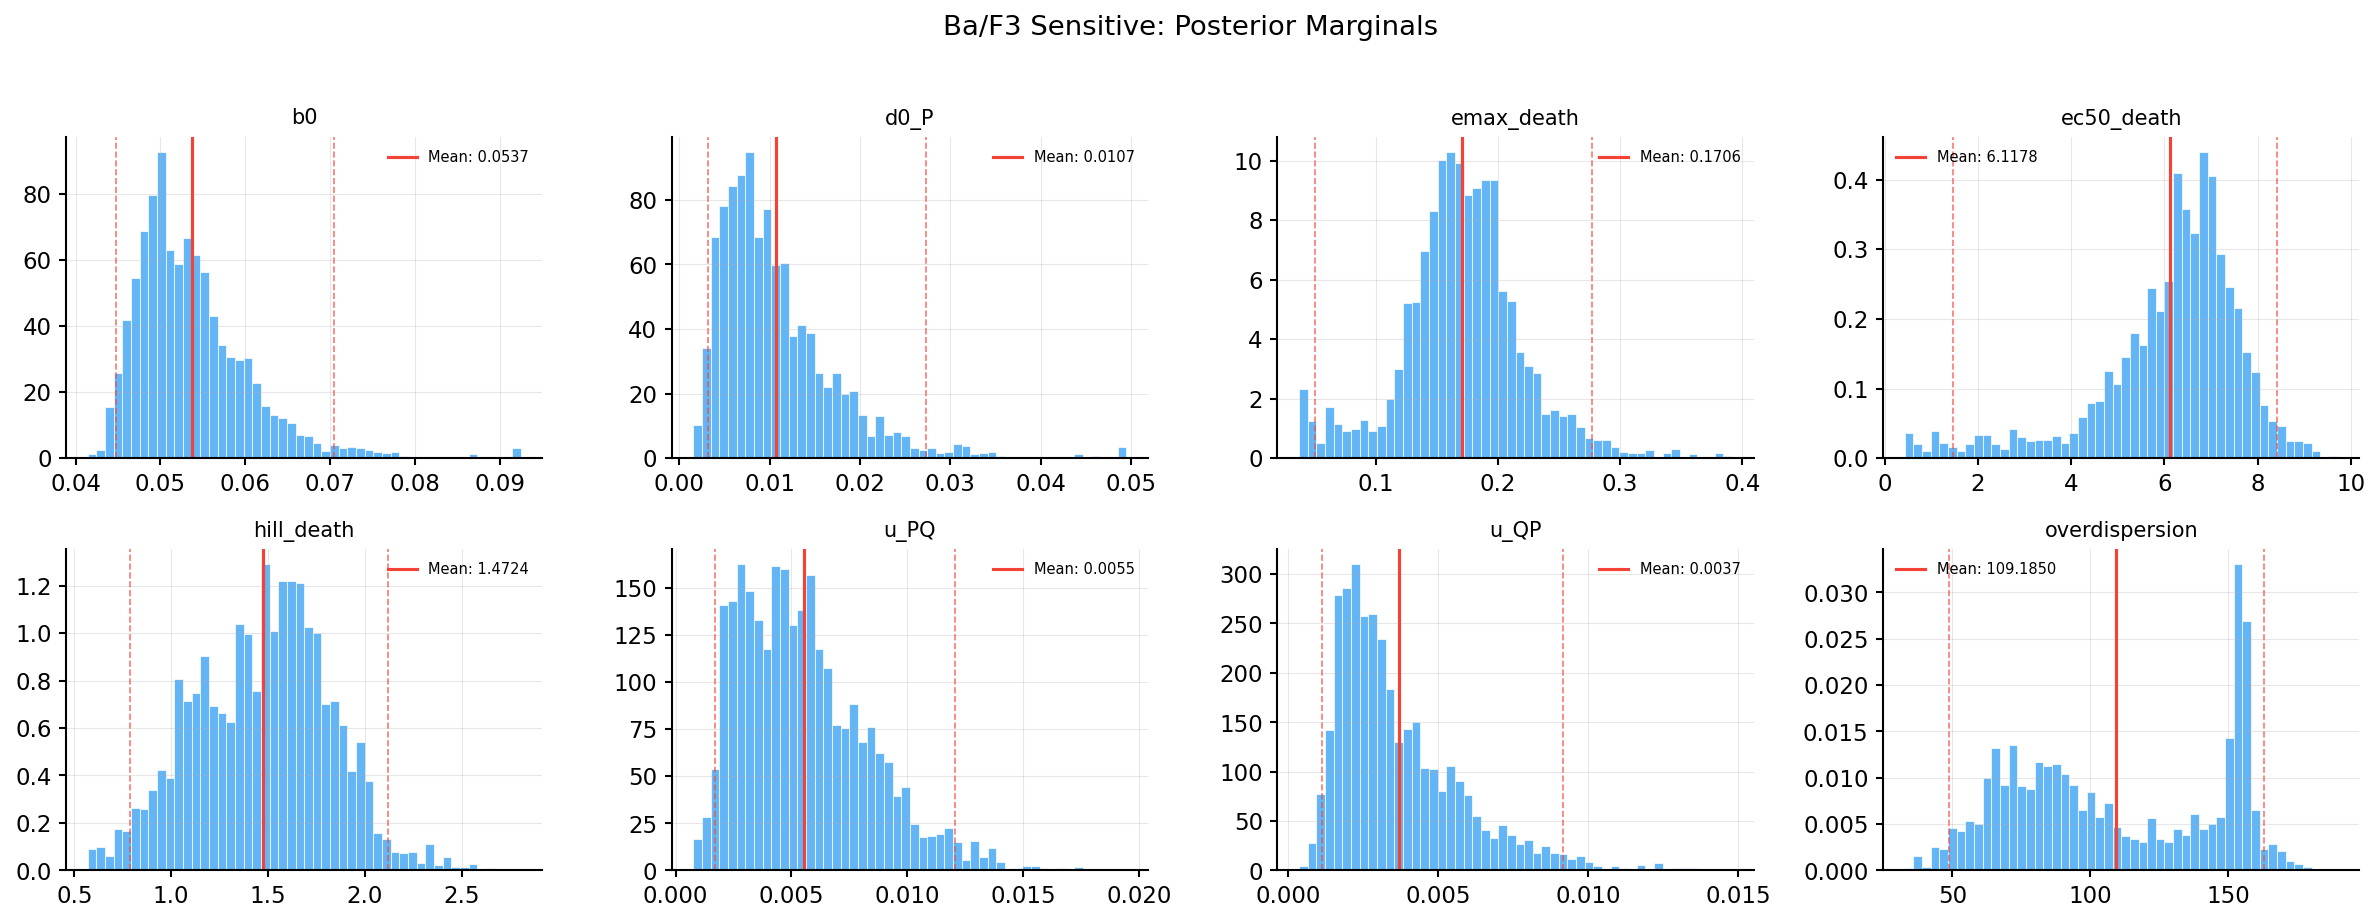

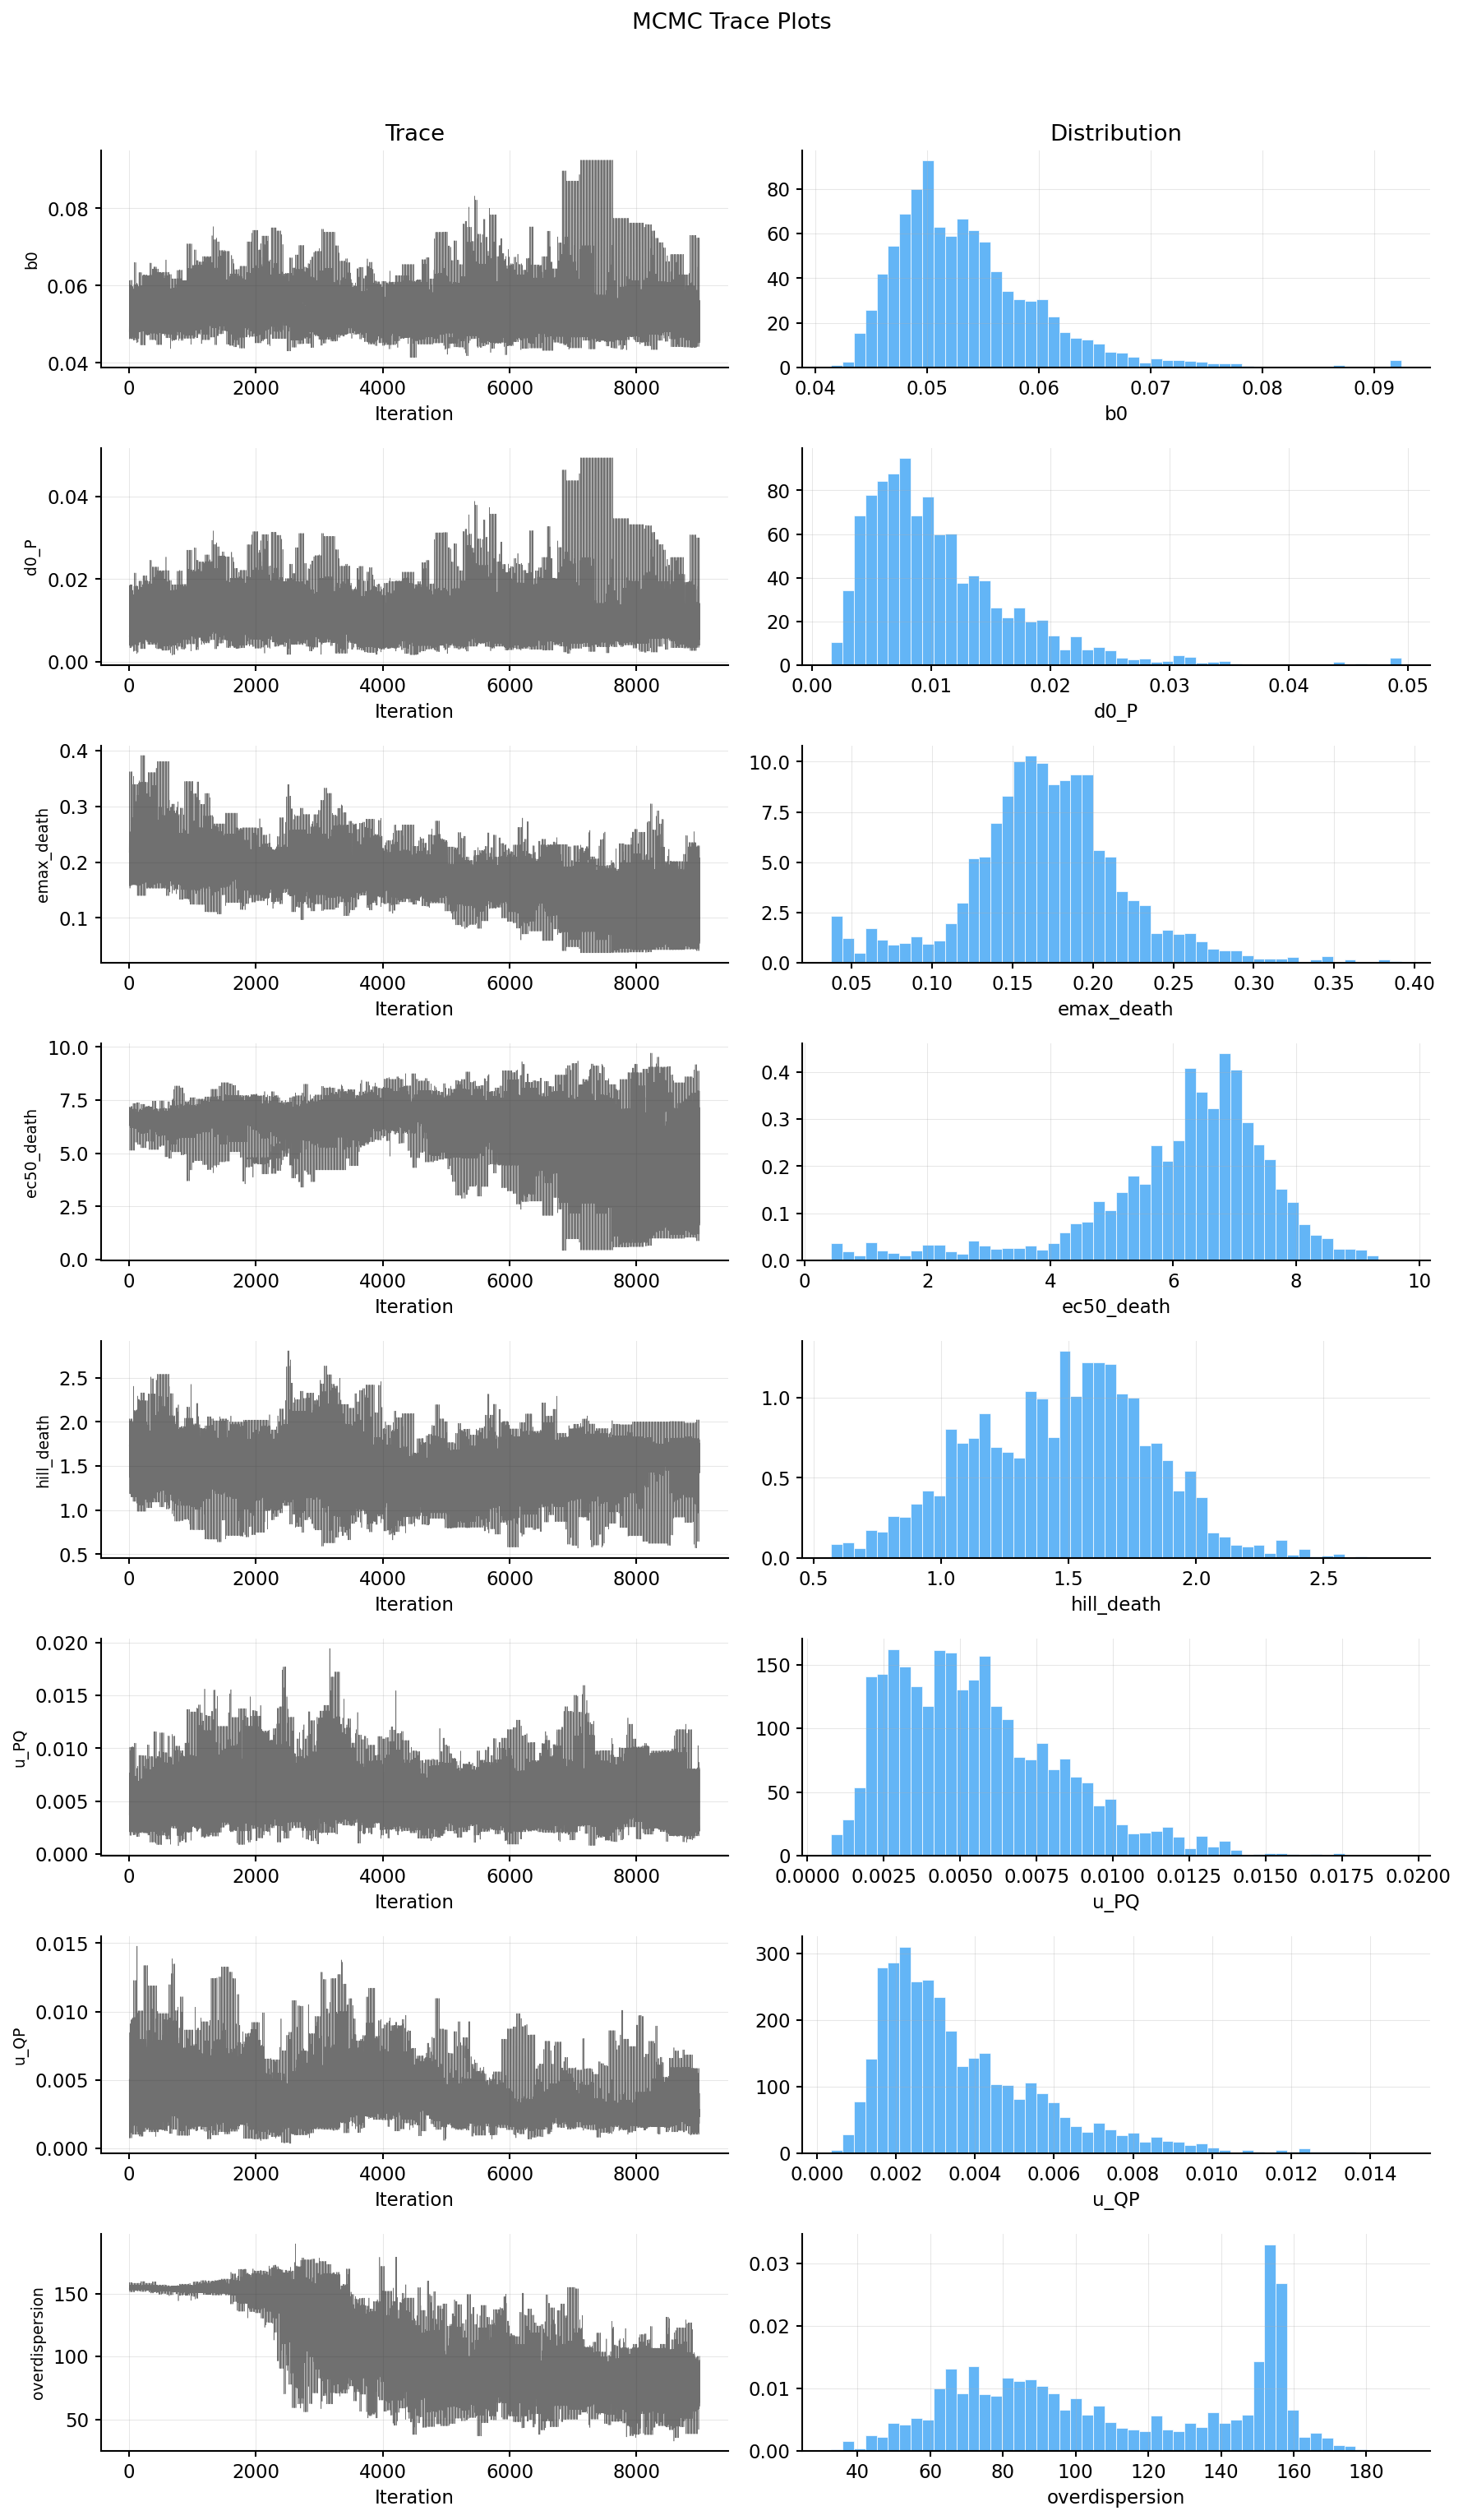

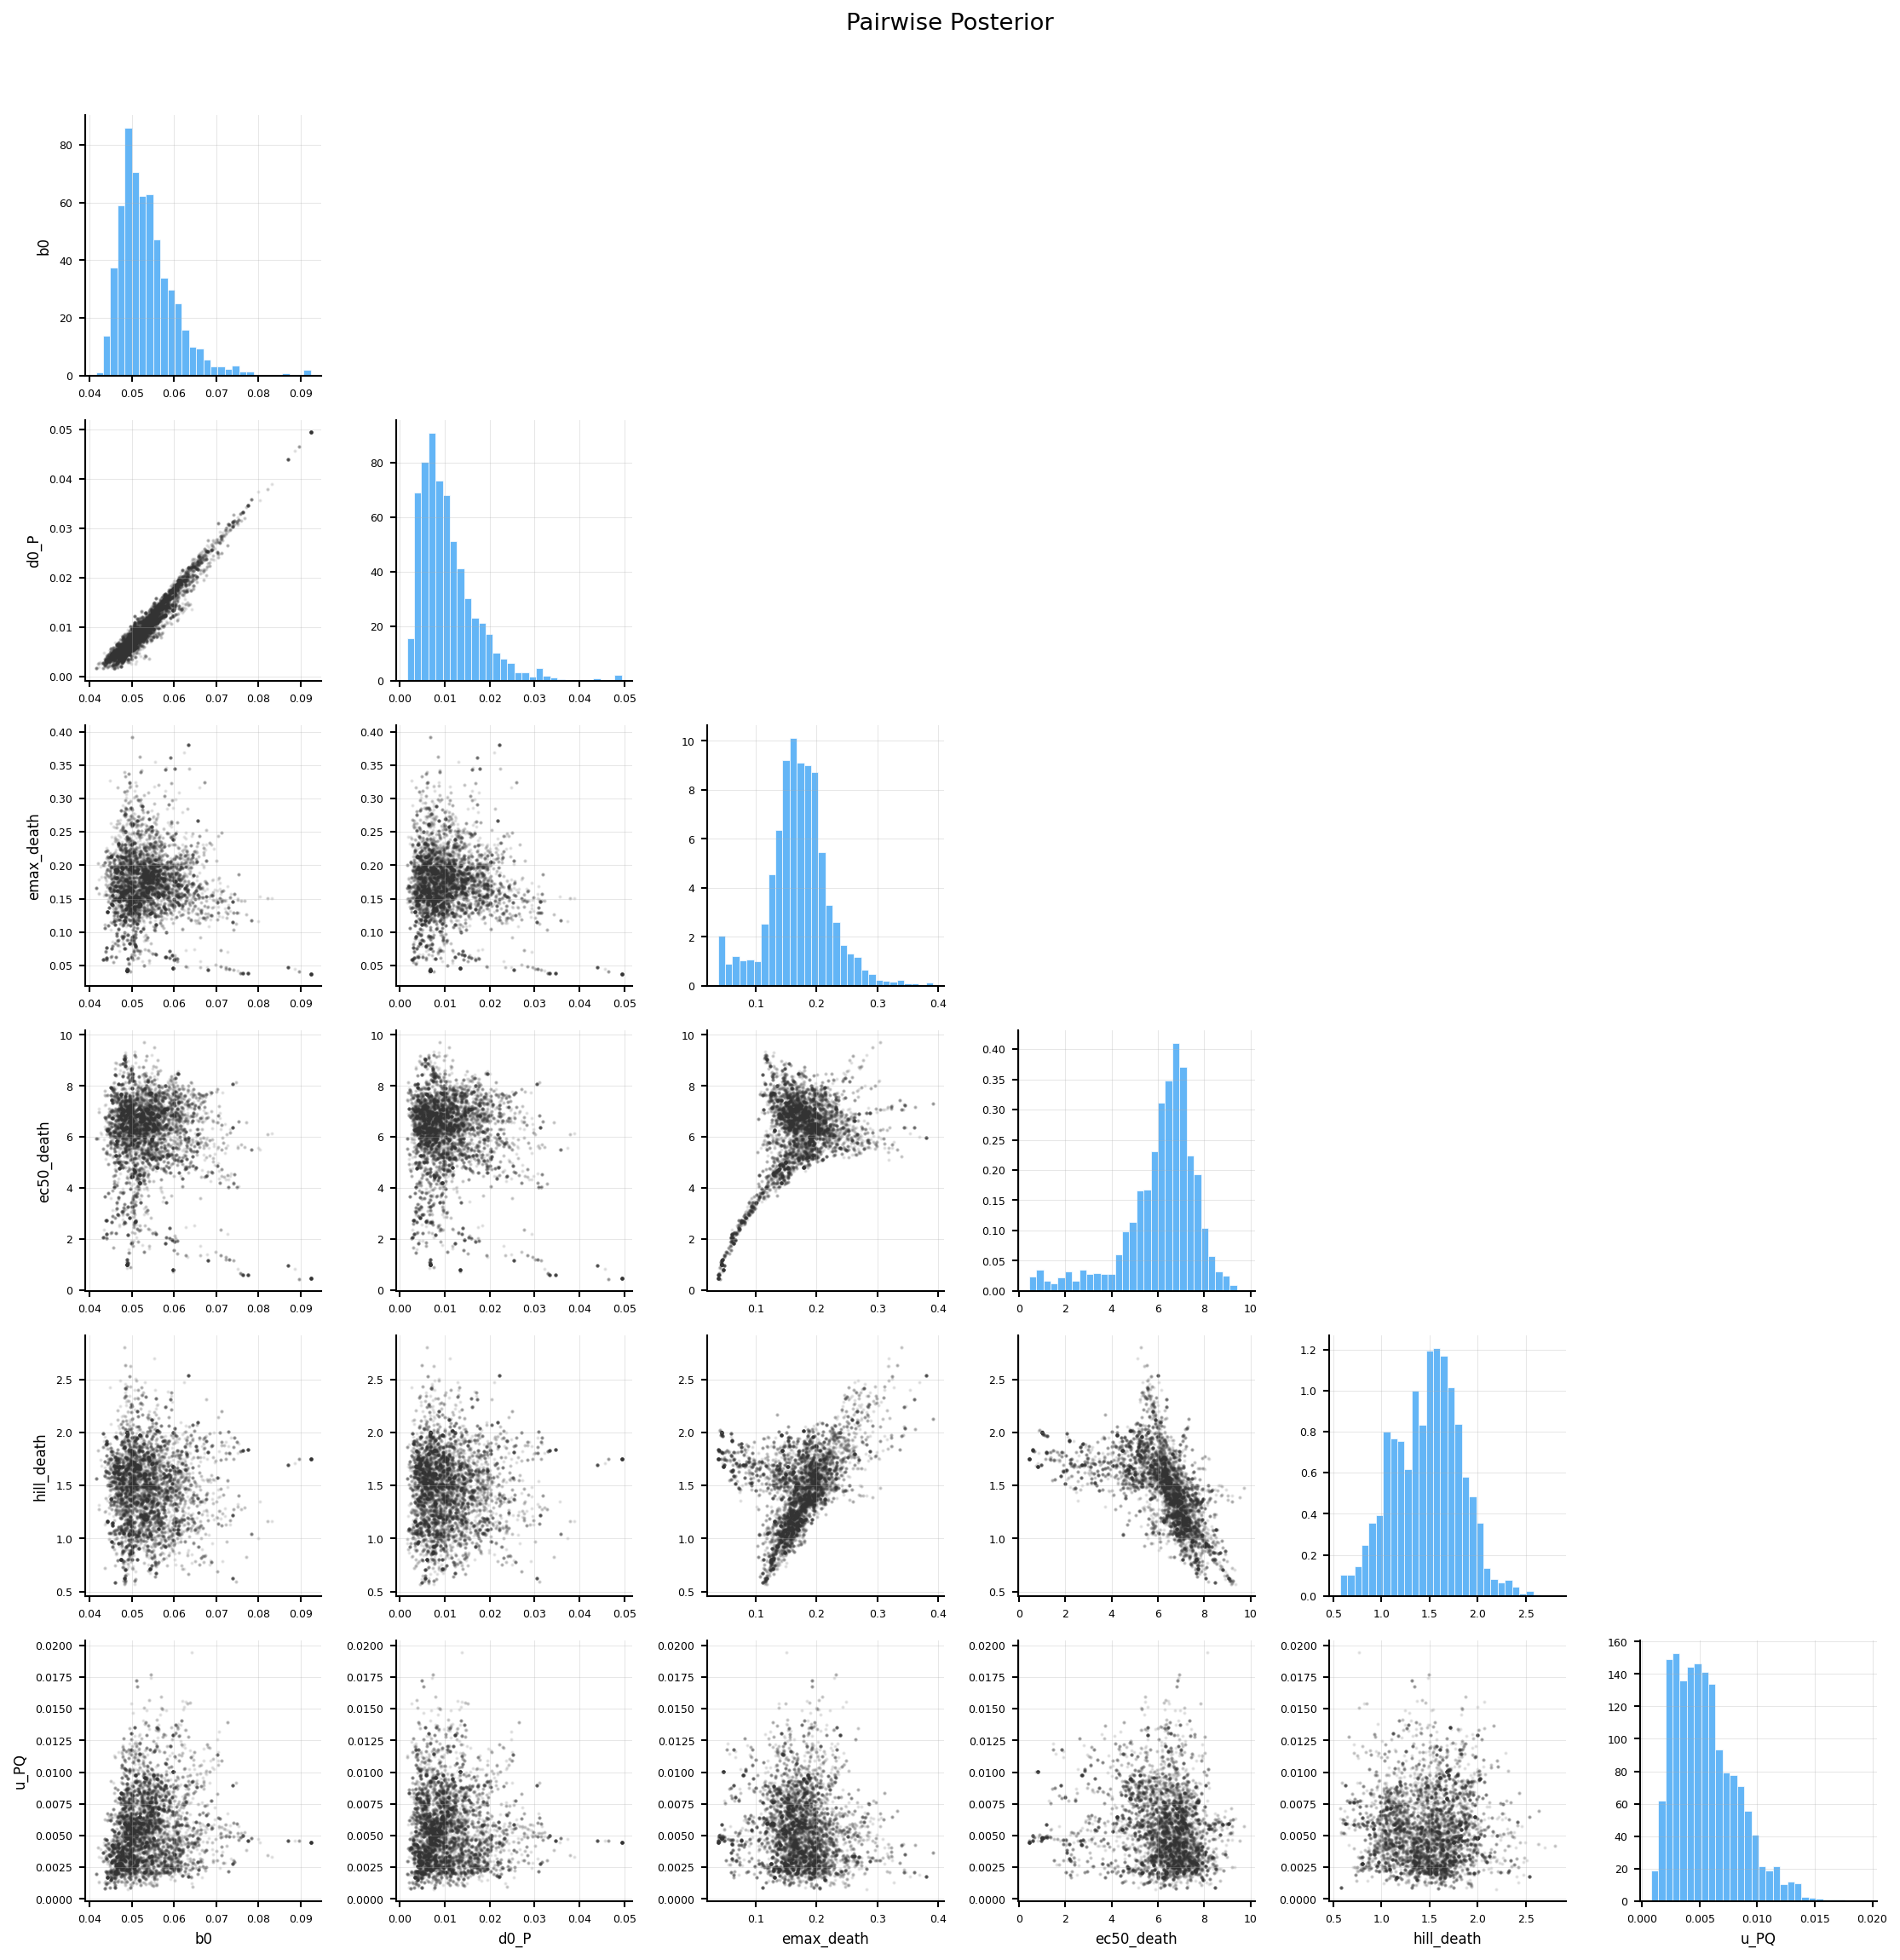

In [15]:
# --- summarize_mcmc ---
diag = summarize_mcmc(mcmc_result)
print("MCMC Diagnostics:")
print(f"{'Parameter':>15} | {'Mean':>10} | {'Std':>10} | {'R-hat':>8} | {'ESS':>8}")
print("-" * 62)
for name, entry in diag.items():
    rhat_str = f"{entry['rhat']:.4f}" if entry['rhat'] is not None else "   N/A"
    print(f"{name:>15} | {entry['mean']:>10.4f} | {entry['std']:>10.4f} | {rhat_str:>8} | {entry['ess']:>8.1f}")

# --- Posterior predictive check ---
ppc = posterior_predictive_check(mcmc_result, lik_mcmc, mcmc_data, n_sim=50)
print(f"\nPPC: mean_LL={ppc['mean_ll']:.2f}, std_LL={ppc['std_ll']:.2f}")

# --- Visualization ---
fig = plot_posterior_marginals(mcmc_result)
plt.suptitle("Ba/F3 Sensitive: Posterior Marginals", y=1.02)
plt.tight_layout()
plt.show()

fig = plot_trace(mcmc_result)
plt.suptitle("MCMC Trace Plots", y=1.02)
plt.tight_layout()
plt.show()

fig = plot_pair(mcmc_result, max_params=6)
plt.suptitle("Pairwise Posterior", y=1.02)
plt.tight_layout()
plt.show()

## 15. Kalman Filter

In [16]:
# --- Build Kalman filter ---
best_params = mle_result.parameters
rate_set_fit = RateSet.cytotoxic_drug(
    b0=best_params['b0'],
    d0=best_params['d0_P'],
    emax_death=best_params['emax_death'],
    ec50_death=best_params['ec50_death'],
    hill_death=best_params['hill_death'],
)

conc_test = 0.5
exposure_kf = lambda t: conc_test
moment_ode_kf = MomentODE(rate_set_fit, topology, exposure_kf)
obs_kf = CellCountObservation(overdispersion=best_params.get('overdispersion', 10.0))

ekf = ExtendedKalmanFilter(moment_ode_kf, obs_kf)

# Run filter on a real replicate
test_data = lik_data[2]  # a replicate at conc=0.5
initial_mu = np.array([test_data.observations['cell_counts'][0], 0.0])  # P=first count, Q=0
kf_result = ekf.filter(test_data, initial_mu=initial_mu)

print(f"Kalman Filter Result:")
print(f"  Marginal log-likelihood: {kf_result.marginal_log_likelihood:.2f}")
print(f"  Filtered means shape: {kf_result.filtered_means.shape}")
print(f"  Filtered covs shape: {kf_result.filtered_covs.shape}")
print(f"  Innovations shape: {kf_result.innovations.shape if kf_result.innovations is not None else 'None'}")

# Compare to direct likelihood
ll_direct = lik_moment(np.array(list(best_params.values())))
print(f"\n  Kalman marginal LL (1 series): {kf_result.marginal_log_likelihood:.2f}")
print(f"  Full likelihood LL ({len(lik_data)} series): {ll_direct:.2f}")

Kalman Filter Result:
  Marginal log-likelihood: -105.83
  Filtered means shape: (14, 2)
  Filtered covs shape: (14, 2, 2)
  Innovations shape: (14,)

  Kalman marginal LL (1 series): -105.83
  Full likelihood LL (4 series): -341.69


## 16. Pharmacokinetics & Exposure

Imatinib PK: oral absorption, T½ ~ 18h, Vd ~ 435 L.

Single bolus: 1 dose(s)
Oral repeated: 3 dose(s)
IV repeated: 3 dose(s)


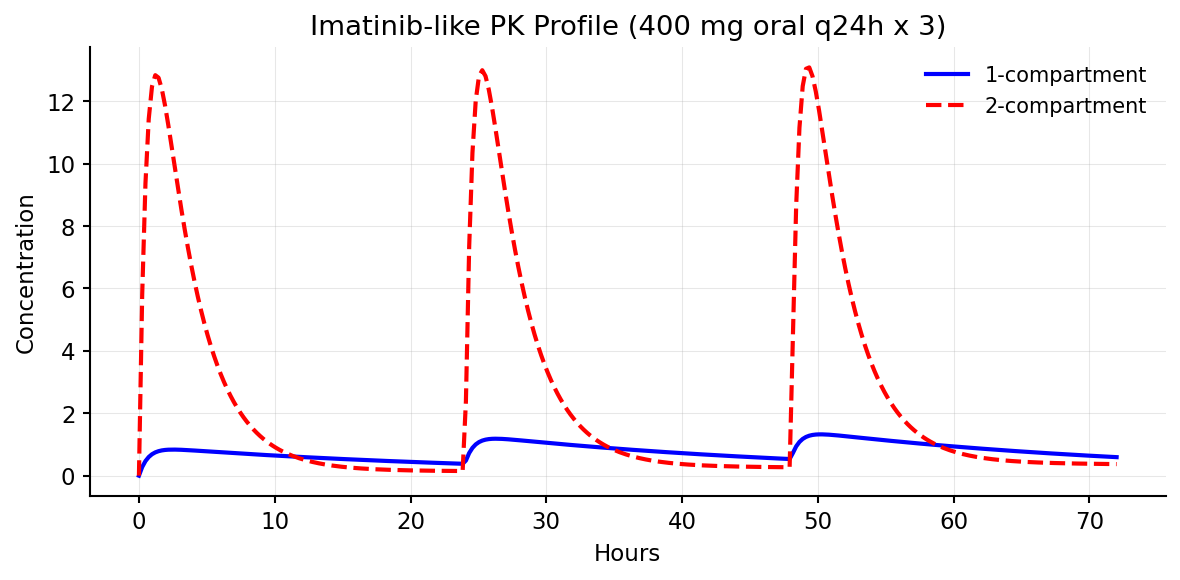


Constant exposure at t=10h: 1.00 uM
PK exposure at t=10h: 0.6452

LuciferinKinetics:
  Peak time: 5.1 min
  Signal fraction at t=10 min: 0.9536
  Signal fraction at peak (5.1 min): 1.0000
  90% imaging window: 1.8 – 13.5 min

TissueAttenuation:
  Factor at 2mm depth: 0.5488
  Factor at 5mm depth: 0.2231
  Factor for 500mm³ tumor: 0.1253


In [17]:
# --- One-compartment PK (Imatinib-like) ---
pk_1c = OneCompartmentPK(
    vd=435.0,       # Volume of distribution (L)
    ke=0.038,       # Elimination rate (1/h), T½ ~ 18h
    ka=1.5,         # Absorption rate (oral)
)

# Dosing schedules
schedule_single = DosingSchedule.single_bolus(dose_amount=400.0, time=0.0)
schedule_oral = DosingSchedule.oral_repeated(
    dose_amount=400.0, interval=24.0, n_doses=3, start_time=0.0
)
schedule_repeat = DosingSchedule.repeated(
    dose_amount=400.0, interval=24.0, n_doses=3, start_time=0.0
)

print(f"Single bolus: {len(schedule_single.doses)} dose(s)")
print(f"Oral repeated: {len(schedule_oral.doses)} dose(s)")
print(f"IV repeated: {len(schedule_repeat.doses)} dose(s)")

# --- Two-compartment PK ---
pk_2c = TwoCompartmentPK(vc=20.0, vp=200.0, cl=5.0, q=2.0, ka=1.5)
t_pk = np.linspace(0, 72, 300)
conc_1c = pk_1c.solve(schedule_oral, t_pk)
conc_2c = pk_2c.solve(schedule_oral, t_pk)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_pk, conc_1c, 'b-', linewidth=2, label='1-compartment')
ax.plot(t_pk, conc_2c, 'r--', linewidth=2, label='2-compartment')
ax.set_xlabel("Hours")
ax.set_ylabel("Concentration")
ax.set_title("Imatinib-like PK Profile (400 mg oral q24h x 3)")
ax.legend()
plt.tight_layout()
plt.show()

# --- ExposureProfile ---
exposure_const = ExposureProfile.constant(1.0)  # in vitro
exposure_pk = ExposureProfile.from_pk(pk_1c, schedule_oral)  # in vivo

print(f"\nConstant exposure at t=10h: {float(exposure_const.concentration(10.0)):.2f} uM")
print(f"PK exposure at t=10h: {float(exposure_pk.concentration(10.0)):.4f}")

# --- Luciferin kinetics (substrate bioavailability model) ---
luc = LuciferinKinetics(dose=150.0, ka_luc=0.5, ke_luc=0.05, km=50.0)
print(f"\nLuciferinKinetics:")
print(f"  Peak time: {luc.peak_time:.1f} min")
# Signal fraction at 10 min post-injection
sig_10 = luc.signal_fraction(10.0)
sig_peak = luc.signal_fraction(luc.peak_time)
print(f"  Signal fraction at t=10 min: {sig_10:.4f}")
print(f"  Signal fraction at peak ({luc.peak_time:.1f} min): {sig_peak:.4f}")
window = luc.optimal_imaging_window(tolerance=0.9)
print(f"  90% imaging window: {window[0]:.1f} – {window[1]:.1f} min")

# --- Tissue attenuation ---
atten = TissueAttenuation(mu_eff=0.3, reference_depth=2.0)
atten_shallow = atten.attenuation_factor(depth=2.0)
atten_deep = atten.attenuation_factor(depth=5.0)
atten_vol = atten.attenuation_factor(volume=500.0)  # estimate depth from volume
print(f"\nTissueAttenuation:")
print(f"  Factor at 2mm depth: {atten_shallow:.4f}")
print(f"  Factor at 5mm depth: {atten_deep:.4f}")
print(f"  Factor for 500mm³ tumor: {atten_vol:.4f}")

## 17. Transfer Learning

Use the MCMC posterior from sensitive Ba/F3 as informative priors for
a hypothetical in vivo model.

Transfer Learning Summary:
  Parameters transferred: 5
  Shrinkage: 0.8

      Parameter |   Prior Mean |    Prior Std
---------------------------------------------
             b0 |      0.05385 |      0.00792
           d0_P |      0.01173 |      0.00950
     emax_death |      0.17860 |      0.08394
     ec50_death |      6.58694 |      3.62980
     hill_death |      1.50301 |      0.49634


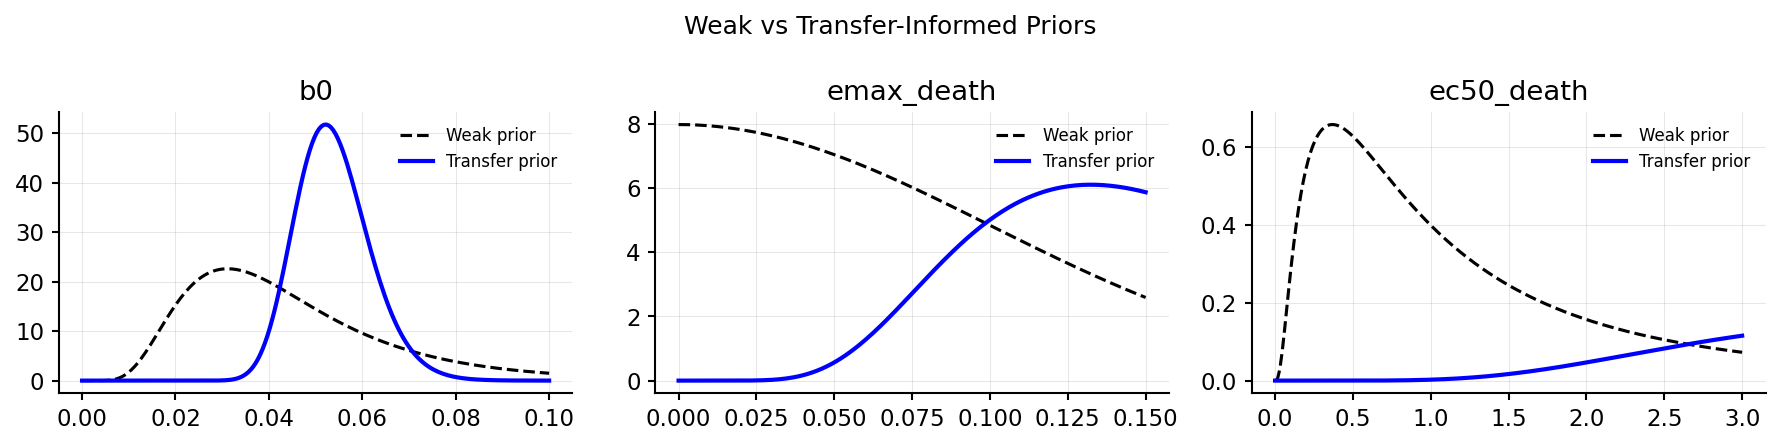

In [18]:
# Package MCMC result as InferenceResult
invitro_result = InferenceResult(
    method="mcmc",
    mcmc=mcmc_result,
    mle=mle_result,
    context="in_vitro",
)

# Transfer learning: transfer PD parameters
transfer = TransferLearning(
    invitro_result=invitro_result,
    transfer_params=["b0", "d0_P", "emax_death", "ec50_death", "hill_death"],
    shrinkage=0.8,
)

transferred_priors = transfer.build_priors()
summary = transfer.summarize_transfer()

print(f"Transfer Learning Summary:")
print(f"  Parameters transferred: {summary['n_params_transferred']}")
print(f"  Shrinkage: {summary['shrinkage']}")
print(f"\n{'Parameter':>15} | {'Prior Mean':>12} | {'Prior Std':>12}")
print("-" * 45)
for name, info in summary['parameters'].items():
    print(f"{name:>15} | {info['prior_mean']:>12.5f} | {info['prior_std']:>12.5f}")

# --- Compare weak vs transfer priors ---
weak_priors = PriorSpec.default_invitro()
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
x_ranges = {'b0': (0, 0.1), 'emax_death': (0, 0.15), 'ec50_death': (0, 3.0)}
for ax, pname in zip(axes, ['b0', 'emax_death', 'ec50_death']):
    x = np.linspace(*x_ranges[pname], 200)
    if pname in weak_priors.distributions:
        ax.plot(x, weak_priors.distributions[pname].pdf(x), 'k--', label='Weak prior')
    if pname in transferred_priors.distributions:
        ax.plot(x, transferred_priors.distributions[pname].pdf(x), 'b-', linewidth=2, label='Transfer prior')
    ax.set_title(pname)
    ax.legend(fontsize=8)

plt.suptitle("Weak vs Transfer-Informed Priors", fontsize=12)
plt.tight_layout()
plt.show()

## 18. Pipeline — Config & Experiment

In [19]:
# --- Create ExperimentConfig programmatically ---
config = ExperimentConfig(
    name="BaF3_imatinib_test",
    context="in_vitro",
    dynamics=DynamicsConfig(states=["P", "Q"]),
    dosing=DosingConfig(
        type="constant",
        concentrations=[0.0, 0.5, 1.0, 2.5, 5.0],
    ),
    simulation=SimulationConfig(
        method="ode",
        initial_cells=700,
        t_max=39.0,
        dt_obs=3.0,
        n_replicates=3,
    ),
    seed=42,
)

# --- Create Experiment ---
experiment = Experiment(config)

# --- Simulate (ODE) ---
sim_result = experiment.simulate(method="ode")
print(f"ODE simulation: viable at t=39h = {sim_result.viable[-1]:.0f}")

# --- Dose-response simulation ---
dr_results = experiment.simulate(concentrations=[0.0, 0.5, 2.5])
print(f"Dose-response: {len(dr_results)} concentrations")
for conc, res in dr_results.items():
    print(f"  {conc} µM: viable at t=39h = {res.viable[-1]:.0f}")

# --- Generate synthetic data ---
synth = experiment.generate_synthetic()
print(f"\nSynthetic dataset: {synth.n_series} series")
print(f"Concentrations: {synth.concentrations}")

# --- Show YAML equivalent ---
import yaml
yaml_str = yaml.dump(config.model_dump(), default_flow_style=False, sort_keys=False)
print(f"\nEquivalent YAML config:\n{yaml_str[:500]}...")

ODE simulation: viable at t=39h = 2075
Dose-response: 3 concentrations
  0.0 µM: viable at t=39h = 2075
  0.5 µM: viable at t=39h = 2075
  2.5 µM: viable at t=39h = 2075

Synthetic dataset: 15 series
Concentrations: [0.0, 0.5, 1.0, 2.5, 5.0]

Equivalent YAML config:
name: BaF3_imatinib_test
context: in_vitro
dynamics:
  states:
  - P
  - Q
  density_dependent: false
  carrying_capacity: null
  linear_chain: null
  clearance_rate: 0.1
pk:
  model: none
  vd: 10.0
  ke: 0.1
  ka: null
  vc: null
  vp: null
  cl: null
  q: null
dosing:
  type: constant
  concentrations:
  - 0.0
  - 0.5
  - 1.0
  - 2.5
  - 5.0
  dose_amount: null
  interval: null
  n_doses: null
  start_time: 0.0
observations:
  modalities:
  - cell_counts
  cell_count_overdispersion: 10.0
  bl...


## 19. Sensitive vs Resistant: Comparative MLE

Fit the model separately to sensitive and resistant monoclonal data,
then compare estimated birth/death rates.

Resistant data: 4 series
Fitting resistant...

      Parameter |  Sensitive |  Resistant
------------------------------------------
             b0 |    0.05069 |    0.15963
           d0_P |    0.00860 |    0.10000
     emax_death |    0.26715 |    0.50000
     ec50_death |    6.72908 |   81.43335
     hill_death |    1.82652 |    4.71048
           u_PQ |    0.00128 |    0.00000
           u_QP |    0.05000 |    0.03183
 overdispersion |  155.71656 |  122.81882

Sensitive net growth (0 µM): 0.0421/h
Resistant net growth (0 µM):  0.0596/h


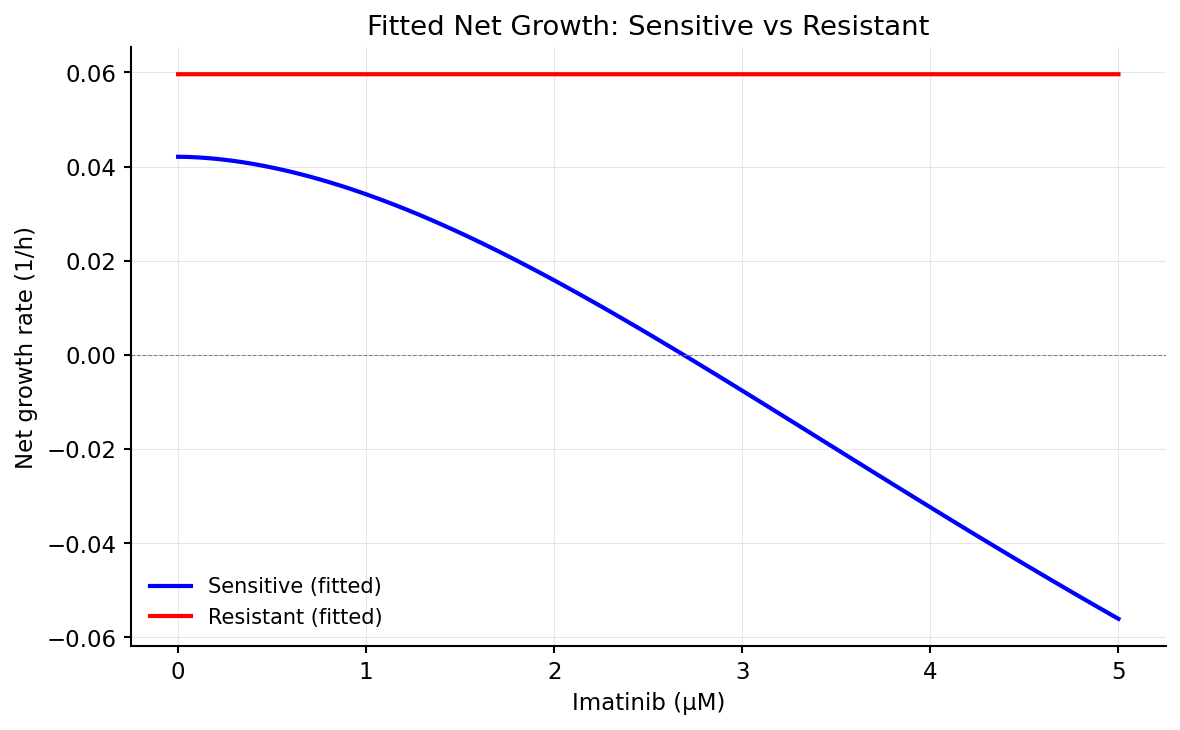

In [20]:
# --- Build resistant data for fitting ---
res500_df = res_df[res_df.initial_cells == 500]
res_reps = res500_df.replicate_id.unique()[:2]
res_lik_data = []
for conc in test_concs:
    for rid in res_reps:
        sub = res500_df[(res500_df.concentration == conc) & (res500_df.replicate_id == rid)]
        sub = sub.sort_values("hours")
        if len(sub) < 2:
            continue
        ts = TimeSeriesData(
            times=sub.hours.values,
            observations={"cell_counts": sub.viable_count.values},
            concentration=float(conc),
            group_id=f"{rid}_c{conc}",
        )
        res_lik_data.append(ts)

print(f"Resistant data: {len(res_lik_data)} series")

# --- Fit resistant ---
lik_res = ModelLikelihood(
    topology=topology, data=res_lik_data,
    mode="moment", observation_model=obs_model
)
est_res = MLEstimator(likelihood=lik_res, method="L-BFGS-B")
print("Fitting resistant...")
mle_res = est_res.fit(n_restarts=5)

# --- Compare ---
print(f"\n{'Parameter':>15} | {'Sensitive':>10} | {'Resistant':>10}")
print("-" * 42)
for name in mle_result.parameters:
    s_val = mle_result.parameters.get(name, float('nan'))
    r_val = mle_res.parameters.get(name, float('nan'))
    print(f"{name:>15} | {s_val:>10.5f} | {r_val:>10.5f}")

print(f"\nSensitive net growth (0 µM): {mle_result.parameters['b0'] - mle_result.parameters['d0_P']:.4f}/h")
print(f"Resistant net growth (0 µM):  {mle_res.parameters['b0'] - mle_res.parameters['d0_P']:.4f}/h")

# --- Plot fitted dose-response curves ---
fig, ax = plt.subplots(figsize=(8, 5))
concs_plot = np.linspace(0, 5, 100)
ng_sens = [mle_result.parameters['b0'] - mle_result.parameters['d0_P']
           - EmaxHill(emax=mle_result.parameters['emax_death'],
                      ec50=mle_result.parameters['ec50_death'],
                      hill=mle_result.parameters['hill_death'])(c)
           for c in concs_plot]
ng_res = [mle_res.parameters['b0'] - mle_res.parameters['d0_P']
          - EmaxHill(emax=mle_res.parameters['emax_death'],
                     ec50=mle_res.parameters['ec50_death'],
                     hill=mle_res.parameters['hill_death'])(c)
          for c in concs_plot]

ax.plot(concs_plot, ng_sens, 'b-', linewidth=2, label='Sensitive (fitted)')
ax.plot(concs_plot, ng_res, 'r-', linewidth=2, label='Resistant (fitted)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel("Imatinib (µM)")
ax.set_ylabel("Net growth rate (1/h)")
ax.set_title("Fitted Net Growth: Sensitive vs Resistant")
ax.legend()
plt.tight_layout()
plt.show()

## 20. Mixture Analysis

Compare model predictions for mixture populations using the independently
fitted sensitive and resistant parameters.

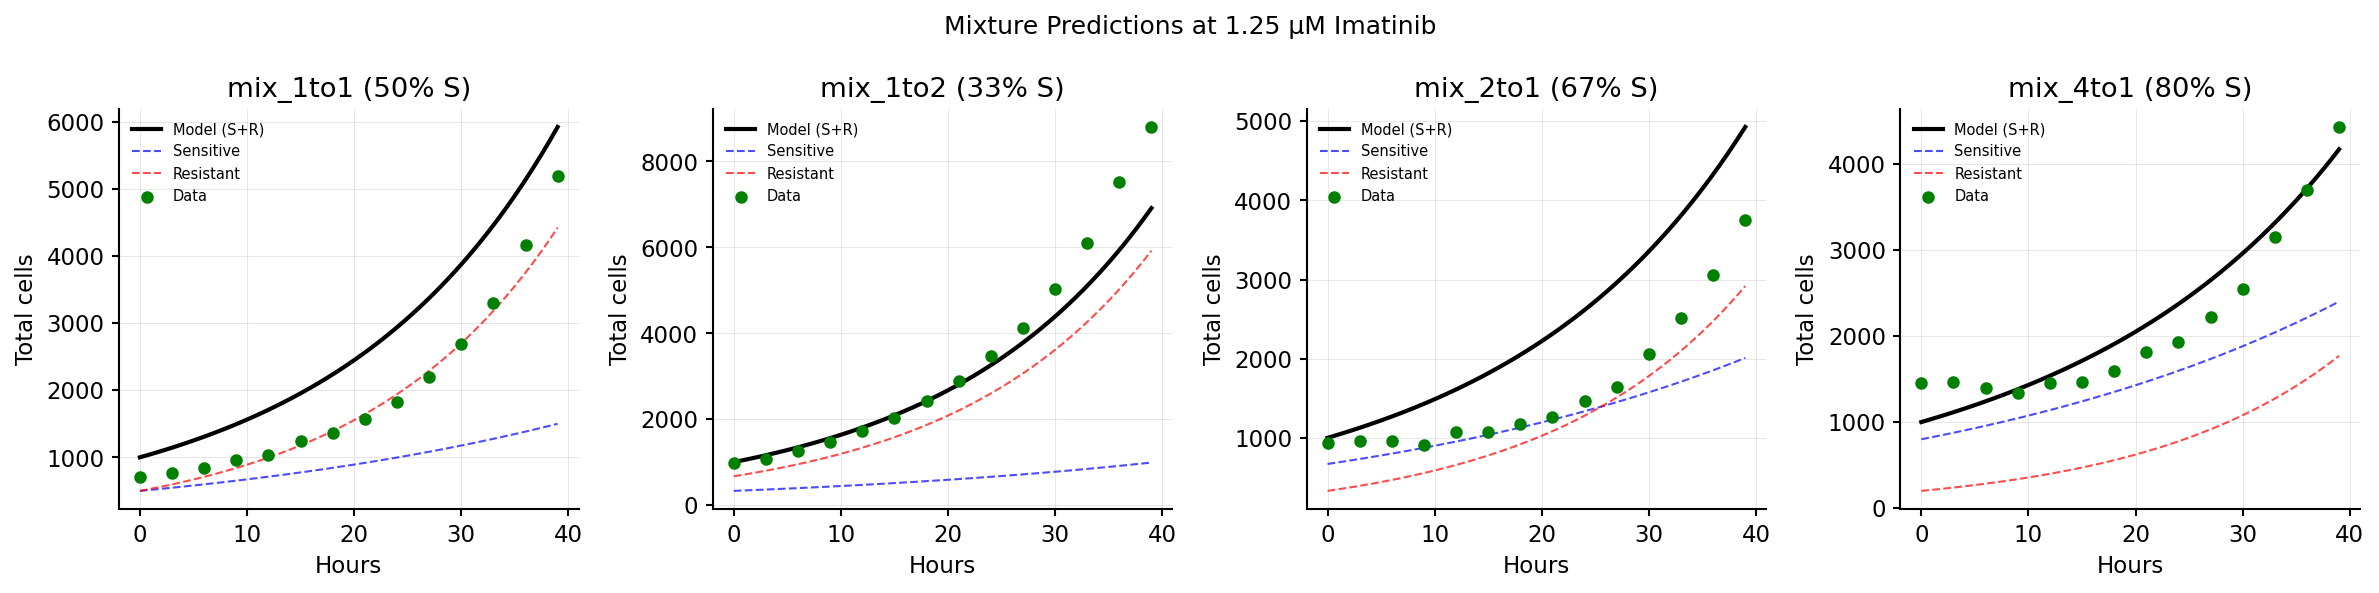

In [21]:
# --- Simulate mixtures using fitted parameters ---
# Build rate sets from fitted parameters
rs_fit_s = RateSet.cytotoxic_drug(
    b0=mle_result.parameters['b0'],
    d0=mle_result.parameters['d0_P'],
    emax_death=mle_result.parameters['emax_death'],
    ec50_death=mle_result.parameters['ec50_death'],
    hill_death=mle_result.parameters['hill_death'],
)
rs_fit_r = RateSet.cytotoxic_drug(
    b0=mle_res.parameters['b0'],
    d0=mle_res.parameters['d0_P'],
    emax_death=mle_res.parameters['emax_death'],
    ec50_death=mle_res.parameters['ec50_death'],
    hill_death=mle_res.parameters['hill_death'],
)

# Predict mixture growth: weighted sum of independent ODE solutions
mixtures = {
    'mix_1to1': 0.50,
    'mix_1to2': 0.33,
    'mix_2to1': 0.67,
    'mix_4to1': 0.80,
}

t_sim = np.linspace(0, 39, 50)
conc_mix = 1.25  # moderate dose where resistant/sensitive differ

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (pop_name, frac_s) in zip(axes, mixtures.items()):
    # Simulate sensitive and resistant independently
    init_total = 1000
    n_s = int(init_total * frac_s)
    n_r = init_total - n_s

    ode_s = build_ode_system(rs_fit_s, topology, constant_concentration=conc_mix)
    ode_r = build_ode_system(rs_fit_r, topology, constant_concentration=conc_mix)

    res_s = ode_s.solve(np.array([float(n_s), 0.0]), (0, 39), t_sim)
    res_r = ode_r.solve(np.array([float(n_r), 0.0]), (0, 39), t_sim)

    predicted_total = res_s.viable + res_r.viable

    ax.plot(t_sim, predicted_total, 'k-', linewidth=2, label='Model (S+R)')
    ax.plot(t_sim, res_s.viable, 'b--', linewidth=1, alpha=0.7, label='Sensitive')
    ax.plot(t_sim, res_r.viable, 'r--', linewidth=1, alpha=0.7, label='Resistant')

    # Overlay real mixture data
    sub = mix_df[(mix_df.population == pop_name) & (mix_df.concentration == conc_mix)]
    if len(sub) > 0:
        mean_mix = sub.groupby("hours").viable_count.mean()
        ax.scatter(mean_mix.index, mean_mix.values, c='green', s=25,
                  zorder=5, label='Data')

    ax.set_title(f"{pop_name} ({frac_s:.0%} S)")
    ax.set_xlabel("Hours")
    ax.set_ylabel("Total cells")
    ax.legend(fontsize=7)

plt.suptitle(f"Mixture Predictions at {conc_mix} µM Imatinib", fontsize=12)
plt.tight_layout()
plt.show()

## 21. Summary

### Functions Tested

| Module | Functions | Status |
|--------|----------|--------|
| **Data** | `load_csv`, `TimeSeriesData`, `ExperimentalDataset`, `log_transform`, `normalize_to_control`, `interpolate_missing` | Tested |
| **Dynamics** | `ModelTopology` (2/3/4-state), `StateVector`, `RateSet` (cytotoxic/cytostatic), `EmaxHill`, `ConstantRate` | Tested |
| **ODE** | `CellDynamicsODE`, `build_ode_system`, `solve_dose_response` | Tested |
| **Stochastic** | `GillespieSimulator`, `TauLeapingSimulator`, `simulate_ensemble`, `EnsembleResult` | Tested |
| **Moments** | `MomentODE` (LNA) | Tested |
| **Observations** | `CellCountObservation`, `BLIObservation`, `TumorVolumeObservation`, `BiomarkerObservation`, `MultimodalObservation` | Tested |
| **Inference** | `ModelLikelihood` (moment + ODE), `MLEstimator`, `MCMCSampler`, `PriorSpec` | Tested |
| **Diagnostics** | `summarize_mcmc`, `posterior_predictive_check` | Tested |
| **Kalman** | `ExtendedKalmanFilter` | Tested |
| **PK** | `OneCompartmentPK`, `TwoCompartmentPK`, `DosingSchedule`, `ExposureProfile`, `LuciferinKinetics`, `TissueAttenuation` | Tested |
| **Transfer** | `TransferLearning`, `build_priors`, `summarize_transfer` | Tested |
| **Pipeline** | `ExperimentConfig`, `Experiment`, `simulate`, `generate_synthetic` | Tested |
| **Visualization** | `plot_rate_dose_response`, `plot_net_growth_curve`, `plot_mechanism_comparison`, `plot_dose_response_trajectories`, `plot_ensemble`, `plot_posterior_marginals`, `plot_trace`, `plot_pair` | Tested |

### Key Findings

- **Dense time-series** (14 timepoints) provides much richer information than endpoint-only data
- **Sensitive vs resistant** Ba/F3 cells show clearly different drug response profiles
- **Mixture predictions** from independently fitted subpopulation parameters
- **LNA mean matches ODE** solution as expected (LNA adds variance information)
- **Stochastic methods** (Gillespie and tau-leaping) agree in mean and variance